# EDA

In [4449]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = "../data/df_table.csv"

df = pd.read_csv(DATA_PATH)

# df = pd.read_csv('df_table.csv')

print(df.shape)
df.head()

(5296, 16)


,brand,model,generation,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,steering_wheel,color,kz_registration,imgs_count,price
0,Chevrolet,Cobalt,2011 - н.в. 2 поколение\n,2021,"Астана, Акмолинская область",Седан,бензин,1.5,145113,Автомат,Передний привод,Слева,черный,Да,25,4490000
1,Chevrolet,Monza,2022 - н.в. 2 поколение рестайлинг\n,2023,"Астана, Акмолинская область",Седан,бензин,1.5,20000,Робот,Передний привод,Слева,серый металлик,Да,6,6400000
2,Chevrolet,Captiva,2018 - н.в. 2 поколение\n,2021,"Алматы, Алматинская область",Внедорожник,бензин,1.5,85024,Автомат,Передний привод,Слева,серый,Да,27,7150000
3,Chevrolet,Cruze,2012 - 2015 J300 рестайлинг\n,2013,"Алматы, Алматинская область",Хэтчбек,бензин,1.8,146000,Автомат,Передний привод,Слева,серебристый,Да,8,4400000
4,Chevrolet,Aveo,2006 - 2012 T250 рестайлинг (T250/T255)\n,2007,"Астана, Акмолинская область",Седан,бензин,1.4,216000,Автомат,Передний привод,Слева,unknown,Да,10,2450000


In [4450]:
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4451]:
for i in list(df.columns):
  print(i, 'Кол-во пропусков', df[i].isna().sum())
  print(i, 'Кол-во уникальных значений признака', df[i].nunique())
  print(i, 'Тип данных', df[i].dtype, '\n')

print(df.duplicated().sum())

brand Кол-во пропусков 0
brand Кол-во уникальных значений признака 8
brand Тип данных object 

model Кол-во пропусков 0
model Кол-во уникальных значений признака 385
model Тип данных object 

generation Кол-во пропусков 6
generation Кол-во уникальных значений признака 592
generation Тип данных object 

year Кол-во пропусков 0
year Кол-во уникальных значений признака 44
year Тип данных int64 

city Кол-во пропусков 0
city Кол-во уникальных значений признака 112
city Тип данных object 

body_type Кол-во пропусков 0
body_type Кол-во уникальных значений признака 14
body_type Тип данных object 

fuel_type Кол-во пропусков 0
fuel_type Кол-во уникальных значений признака 6
fuel_type Тип данных object 

engine_volume Кол-во пропусков 0
engine_volume Кол-во уникальных значений признака 51
engine_volume Тип данных float64 

mileage Кол-во пропусков 0
mileage Кол-во уникальных значений признака 1561
mileage Тип данных int64 

transmission Кол-во пропусков 0
transmission Кол-во уникальных значений

Уберем 3 копии строк с сохранением первого вхождения

In [4452]:
df.drop_duplicates(inplace=True)

In [4453]:
num_cols = ["year", "engine_volume", "mileage", "imgs_count", "price"]

df[num_cols].describe()

,year,engine_volume,mileage,imgs_count,price
count,5293.000000,5293.000000,5293.000000,5293.000000,5.293000e+03
mean,2012.553183,2.620688,174512.165879,15.094275,1.130261e+07
std,9.290702,1.033807,123642.852020,11.545319,1.043994e+07
min,1977.000000,0.000000,1.000000,0.000000,2.000000e+06
25%,2006.000000,2.000000,80000.000000,8.000000,4.600000e+06
50%,2014.000000,2.500000,152000.000000,12.000000,7.780000e+06
75%,2021.000000,3.000000,248000.000000,20.000000,1.380000e+07
max,2026.000000,8.000000,999999.000000,99.000000,6.000000e+07


In [4454]:
cat_cols = ["brand", "model", "generation", "city", "body_type", "fuel_type", "transmission", "drive_type", "steering_wheel", "color", "kz_registration"]

for i in cat_cols:
  print(i, 'Кол-во пропусков', df[i].isna().sum())
  print(i, 'Кол-во уникальных значений', df[i].nunique())
  print(i, 'Тип данных', df[i].dtype, '\n')

for i in cat_cols:
  if df[i].nunique() < 50:
    print(i, ':', df[i].unique())

brand Кол-во пропусков 0
brand Кол-во уникальных значений 8
brand Тип данных object 

model Кол-во пропусков 0
model Кол-во уникальных значений 385
model Тип данных object 

generation Кол-во пропусков 6
generation Кол-во уникальных значений 592
generation Тип данных object 

city Кол-во пропусков 0
city Кол-во уникальных значений 112
city Тип данных object 

body_type Кол-во пропусков 0
body_type Кол-во уникальных значений 14
body_type Тип данных object 

fuel_type Кол-во пропусков 0
fuel_type Кол-во уникальных значений 6
fuel_type Тип данных object 

transmission Кол-во пропусков 0
transmission Кол-во уникальных значений 4
transmission Тип данных object 

drive_type Кол-во пропусков 0
drive_type Кол-во уникальных значений 3
drive_type Тип данных object 

steering_wheel Кол-во пропусков 0
steering_wheel Кол-во уникальных значений 2
steering_wheel Тип данных object 

color Кол-во пропусков 0
color Кол-во уникальных значений 40
color Тип данных object 

kz_registration Кол-во пропусков 

In [4455]:
df = df[df["generation"].notna()].copy()
df["generation"] = df["generation"].astype(str).str.strip()

## 1. Generation

У нас есть категориальный признак Generation. Он является категориальным и в нем хранится множество данных, которые нам требуется разбить на подпризнаки:


*   g_start_year - год, в который началось это поколение автомобиля
*   g_end_year - год, в который закончилось это поколение автомобиля
*   g_is_current - метка, актуально ли поколение сейчас?
*   g_number - номер поколения
*   g_is_restyling - является ли это поколение версией рестайлинга
*   g_age_car_release - сколько лет прошло от выпуска поколения до года выпуска авто
*   g_span - сколько длилось поколение




In [4456]:
def g_fe(generation, car_year):

    s = str(generation).lower().strip()
    years = re.findall(r"\d{4}", s) # достаем все годы из строки, ищем в  строке все элементы, состоящие из 4 повторящихся чисел
    start_year, end_year = np.nan, np.nan # закидываем дефолтные значения

    # определаем год запуска и снятия поколения, если поколение актулальное - отмечаем это
    if len(years) >= 1:
        start_year = float(years[0])
    if "н.в" in s: # если у нас есть н.в. в описания поколения, то в end_year кладем текущий год и указываем, что генерация модели актуальная
        end_year = now
        is_current = 1
    else: # иначе в is_current указываем, что генерация модели неактуальная и в end_year кладем значение years[1]
        is_current = 0
        if len(years) >= 2:
            end_year = float(years[1])

    # Достаем номер поколения, если есть фраза "N поколение"
    g_number = np.nan
    match = re.search(r"(\d+)\s*поколение", s)
    if match:
        g_number = float(match.group(1))

    # Есть ли рестайлинг
    if "рестайлинг" in s:
      is_restyling = 1
    else:
      is_restyling = 0

    # diff между годом выпуска авто и годом выпуска поколения
    g_age_car_release = np.nan
    if not np.isnan(start_year):
        g_age_car_release = car_year - start_year

    # Длина поколения
    g_span = np.nan
    if not np.isnan(start_year) and not np.isnan(end_year):
        g_span = end_year - start_year

    return pd.Series({"g_start_year": start_year, "g_end_year": end_year, "g_is_current": is_current, "g_number": g_number, "g_is_restyling": is_restyling, "g_age_car_release": g_age_car_release, "g_span": g_span})

In [4457]:
def get_f(row):
    generation = row["generation"]
    year = row["year"]

    return g_fe(generation, year)

generation_features = df.apply(get_f, axis=1)


# 3. Просто склеиваем старую таблицу df и новую таблицу generation_features
df = pd.concat([df, generation_features], axis=1)


g_cols = ["generation", "year", "g_start_year", "g_end_year", "g_is_current", "g_number", "g_is_restyling", "g_age_car_release", "g_span"]

display(df[g_cols].head(20))

,generation,year,g_start_year,g_end_year,g_is_current,g_number,g_is_restyling,g_age_car_release,g_span
0,2011 - н.в. 2 поколение,2021,2011.0,2026.0,1.0,2.0,0.0,10.0,15.0
1,2022 - н.в. 2 поколение рестайлинг,2023,2022.0,2026.0,1.0,2.0,1.0,1.0,4.0
2,2018 - н.в. 2 поколение,2021,2018.0,2026.0,1.0,2.0,0.0,3.0,8.0
3,2012 - 2015 J300 рестайлинг,2013,2012.0,2015.0,0.0,NaN,1.0,1.0,3.0
4,2006 - 2012 T250 рестайлинг (T250/T255),2007,2006.0,2012.0,0.0,NaN,1.0,1.0,6.0
5,2020 - н.в. 2 поколение рестайлинг,2022,2020.0,2026.0,1.0,2.0,1.0,2.0,6.0
6,2012 - 2015 J300 рестайлинг,2013,2012.0,2015.0,0.0,NaN,1.0,1.0,3.0
7,2020 - н.в. 1 поколение,2021,2020.0,2026.0,1.0,1.0,0.0,1.0,6.0
8,2015 - 2018 9 поколение,2016,2015.0,2018.0,0.0,9.0,0.0,1.0,3.0
9,2020 - н.в. 2 поколение рестайлинг,2023,2020.0,2026.0,1.0,2.0,1.0,3.0,6.0


Рассмотрим невозможные случаи

In [4458]:
bad_case = df[(df["g_age_car_release"] < 0) | (df["g_span"] < 0) | (df["g_start_year"].isna()) | (df["g_end_year"].isna())][g_cols]
bad_case

,generation,year,g_start_year,g_end_year,g_is_current,g_number,g_is_restyling,g_age_car_release,g_span
1209,1998 - 2001 E38 рестайлинг,1995,1998.0,2001.0,0.0,NaN,1.0,-3.0,3.0
4178,2004 - 2007 1 поколение рестайлинг (U2),2003,2004.0,2007.0,0.0,1.0,1.0,-1.0,3.0


In [4459]:
print(df.shape)
df.drop(index=[1209, 4178], inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)

(5287, 23)
(5285, 23)


generation_number иногда отсутствует, н-мер, "2012 - 2015 J300 рестайлинг". Добавляем флаг и заполняем 0.

In [4460]:
df["generation_number_missing"] = df["g_number"].isna().astype(int)
df["g_number"] = df["g_number"].fillna(0)

In [4461]:
bad_case = df[(df["g_age_car_release"] < 0) | (df["g_span"] < 0) | (df["g_start_year"].isna()) | (df["g_end_year"].isna())][g_cols]
bad_case

,generation,year,g_start_year,g_end_year,g_is_current,g_number,g_is_restyling,g_age_car_release,g_span


После обработки всех подпризнаков и рассмотрения корнер-кейсов, можно дровать Generation

In [4462]:
df = df.drop(columns=["generation"])
df.shape

(5285, 23)

Размер сета после работы в признаком Generation: 5285 x 23

In [4463]:
g_cols = ["year", "g_start_year", "g_end_year", "g_is_current", "g_number", "g_is_restyling", "g_age_car_release", "g_span"]
display(df[g_cols].head(20))

,year,g_start_year,g_end_year,g_is_current,g_number,g_is_restyling,g_age_car_release,g_span
0,2021,2011.0,2026.0,1.0,2.0,0.0,10.0,15.0
1,2023,2022.0,2026.0,1.0,2.0,1.0,1.0,4.0
2,2021,2018.0,2026.0,1.0,2.0,0.0,3.0,8.0
3,2013,2012.0,2015.0,0.0,0.0,1.0,1.0,3.0
4,2007,2006.0,2012.0,0.0,0.0,1.0,1.0,6.0
5,2022,2020.0,2026.0,1.0,2.0,1.0,2.0,6.0
6,2013,2012.0,2015.0,0.0,0.0,1.0,1.0,3.0
7,2021,2020.0,2026.0,1.0,1.0,0.0,1.0,6.0
8,2016,2015.0,2018.0,0.0,9.0,0.0,1.0,3.0
9,2023,2020.0,2026.0,1.0,2.0,1.0,3.0,6.0


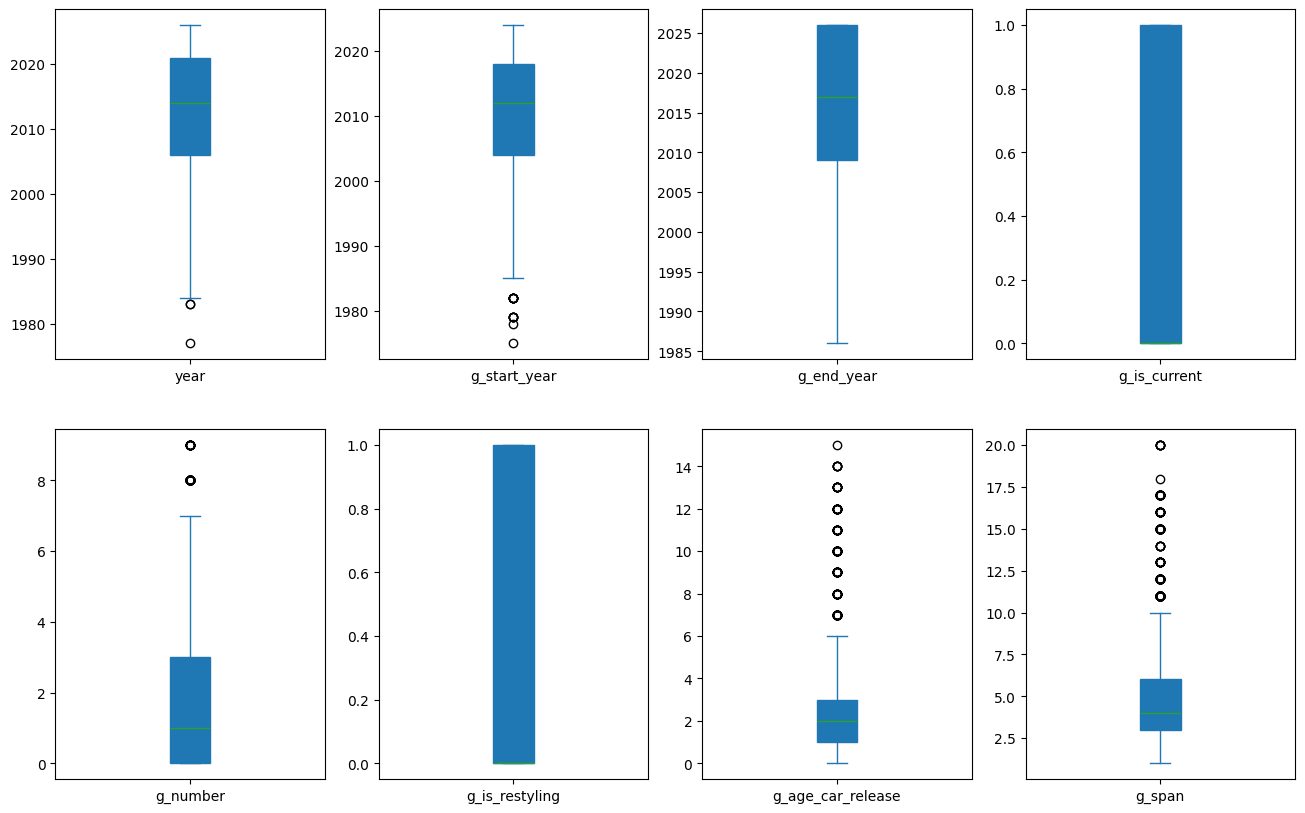

In [4464]:
df[g_cols].plot(kind='box', subplots=True,
    layout=(2, 4),      # Сетка 2 строки, 4 столбца
    figsize=(16, 10),   # Размер общего полотна
    patch_artist=True,  # Закрас
    sharex=False,       # У каждого своя ось X
    sharey=False     )   # У каждого своя ось Y

plt.show()

In [4465]:
print(df['g_is_current'].value_counts())
print(df['g_is_restyling'].value_counts())

g_is_current
0.0    3610
1.0    1675
Name: count, dtype: int64
g_is_restyling
0.0    3398
1.0    1887
Name: count, dtype: int64


In [4466]:
df = df.reset_index(drop=True)

## 2. Price

Теперь рассмотрим цены в общем и в отдельности по брендам

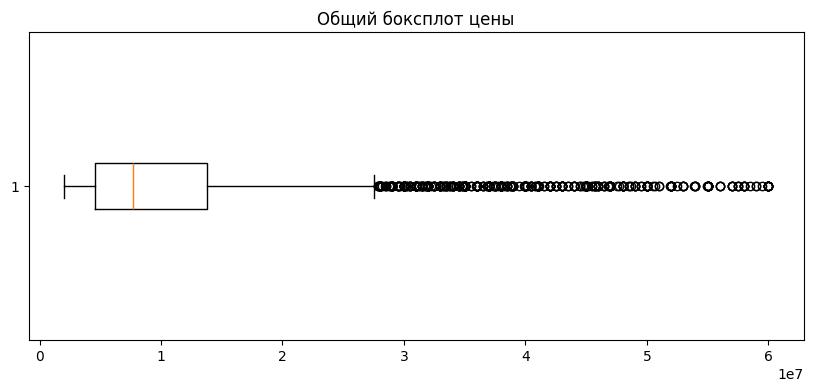

In [4467]:
plt.figure(figsize=(10, 4))
plt.boxplot(df["price"], vert=False)
plt.title("Общий боксплот цены")
plt.show()

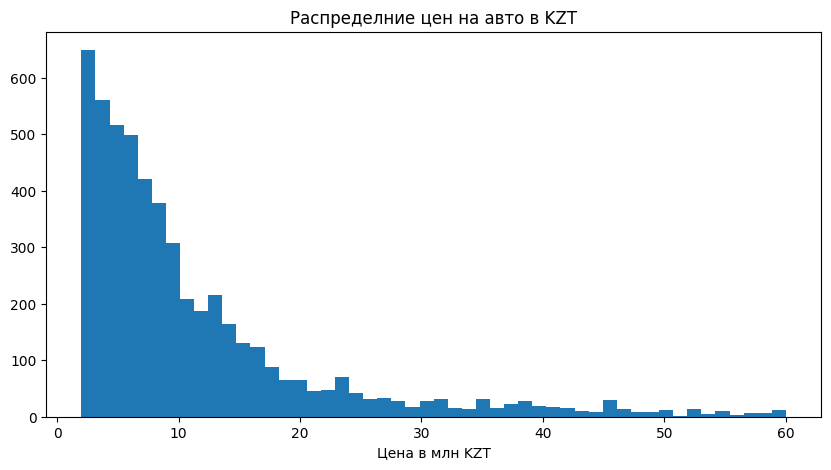

In [4468]:
plt.figure(figsize=(10, 5))
plt.hist(df["price"] / 1_000_000, bins=50)
plt.title("Распределние цен на авто в KZT")
plt.xlabel("Цена в млн KZT")
plt.show()

Распределение цены имеет выраженный правый хвост, большинство автомобилей находится в более низком и среднем ценовом сегменте, но есть небольшая доля дорогих автомобилей. Для обучения удобнее использовать логарифмированный показатель цены: target_log_price, пото что он будет менее чувствителен к дорогим автомобилям

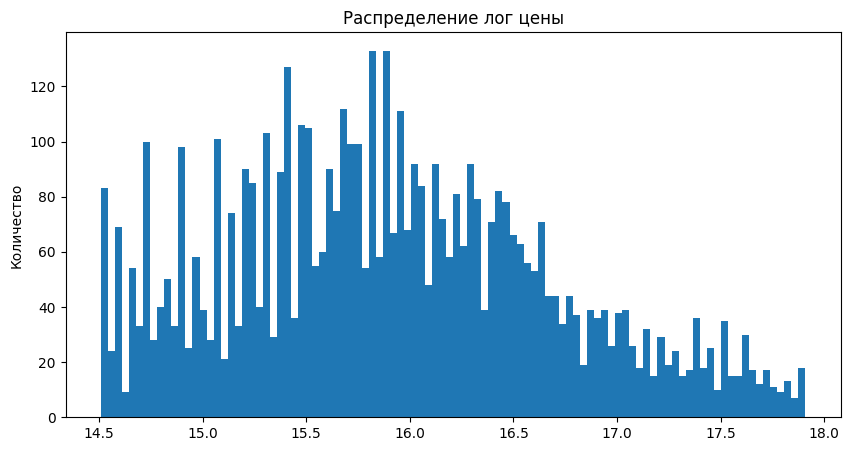

In [4469]:
df["target_log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(df["target_log_price"], bins=100)
plt.title("Распределение лог цены")
plt.ylabel("Количество")
plt.show()

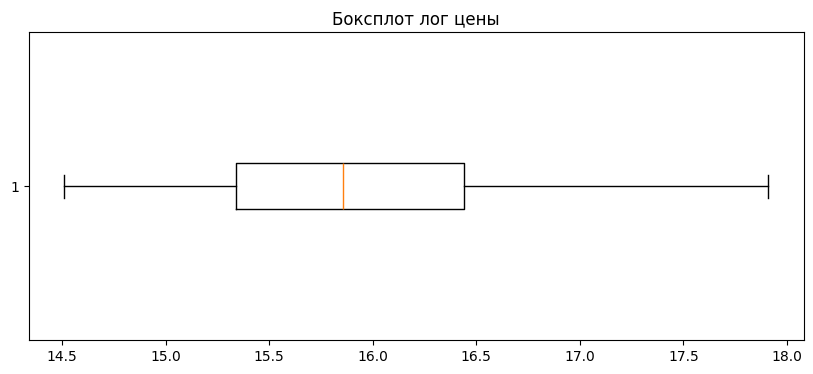

In [4470]:
plt.figure(figsize=(10, 4))
plt.boxplot(df["target_log_price"], vert=False)
plt.title("Боксплот лог цены")
plt.show()

In [4471]:
price_q = df["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
price_q

,price
count,5.285000e+03
mean,1.130492e+07
std,1.044674e+07
min,2.000000e+06
1%,2.000000e+06
5%,2.450000e+06
25%,4.600000e+06
50%,7.700000e+06
75%,1.380000e+07
95%,3.550000e+07


Минимальная цена равна 2 млн KZT, медиана около 7.7 млн KZT, среднее около 11.3 млн KZT, а максимум достигает 60 млн KZT. Среднее заметно выше медианы, что подтверждает правостороннюю асимметрию распределения.

In [4472]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1

niz= max(0, q1 - 1.5 * iqr)
verh = q3 + 1.5 * iqr

print(niz)
print(verh)
print((df["price"] < niz).sum())
print((df["price"] > verh).sum())
print(432/len(df))

0
27600000.0
0
432
0.08174077578051088


По IQR верхняя граница цены 27.6 млн KZT, выше нее находится 432 объявлени, около 8.2% датасета. Это реальные автомобили, поэтому мы не удаляем эти наблюдения.

Чтобы невелировать правый хвост используем target_log_price, те логорифмируем цену

/tmp/ipykernel_3938/1803388855.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(brands, labels=all_brands)


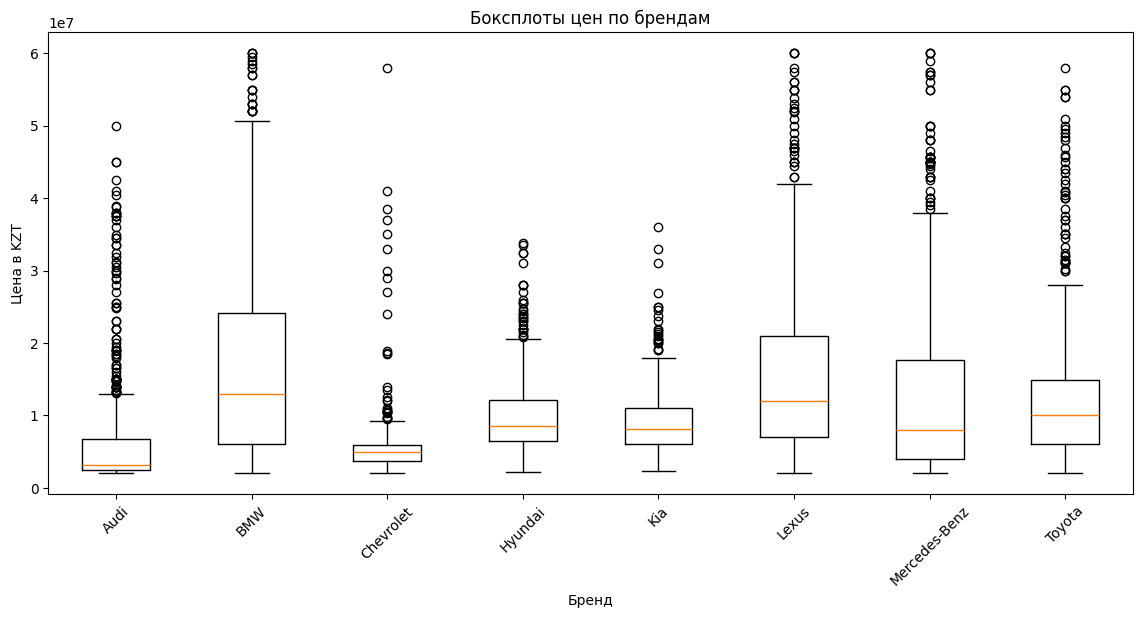

In [4473]:
all_brands = sorted(df["brand"].unique())
brands = []

for i in all_brands:
    q = df[df["brand"] == i]["price"]
    brands.append(q)

plt.figure(figsize=(14, 6))
plt.boxplot(brands, labels=all_brands)

plt.title("Боксплоты цен по брендам")
plt.xlabel("Бренд")
plt.ylabel("Цена в KZT")
plt.xticks(rotation=45)
plt.show()

Боксплот показывает, что бренд является сильным ценовым признаком. Премиальные бренды имеют большие хвосты сверху, массовые бренды находятся в нижнем ценовом диапазоне

Поэтому позже нужно добавить флаг is_premium_brand

Посмотрим на хвосты распределния, проверим на качество данных в этих кейсах

In [4474]:
df.sort_values("price", ascending=False)[["brand", "model", "year", "body_type", "engine_volume", "mileage", "price"]].head(15)

,brand,model,year,body_type,engine_volume,mileage,price
4624,Lexus,GX 550,2025,Внедорожник,3.4,8000,60000000
1248,BMW,X7,2022,Кроссовер,3.0,25000,60000000
4361,Mercedes-Benz,G 63 AMG,2012,Внедорожник,5.5,19000,60000000
4533,Mercedes-Benz,S 500,2022,Седан,3.0,45000,60000000
2068,BMW,X5 M,2022,Кроссовер,4.4,55000,60000000
1504,Lexus,LX 570,2019,Внедорожник,5.7,120000,60000000
2336,BMW,X5,2025,Кроссовер,3.0,5000,60000000
4006,Lexus,GX 550,2024,Внедорожник,3.4,7000,60000000
4326,Mercedes-Benz,GLE 350,2024,Кроссовер,2.0,18000,60000000
4029,BMW,X7,2023,Кроссовер,3.0,40000,59500000


In [4475]:
df.sort_values("price")[["brand", "model", "year", "body_type", "engine_volume", "mileage", "price"]].head(15)

,brand,model,year,body_type,engine_volume,mileage,price
3494,Audi,A6,2006,Седан,3.2,333333,2000000
3553,Audi,100,1993,Седан,2.0,350000,2000000
3546,Audi,A6,2001,Универсал,2.5,777,2000000
3466,BMW,318,1996,Седан,1.8,338000,2000000
1810,Chevrolet,Lacetti,2007,Хэтчбек,1.6,230106,2000000
2908,Audi,100,1991,Седан,2.0,111111,2000000
2902,Audi,80,1992,Седан,2.0,235000,2000000
2922,Audi,100,1992,Седан,2.6,261800,2000000
284,Audi,A8,1995,Седан,2.8,500000,2000000
277,Audi,100,1993,Седан,2.6,111111,2000000


Видим, что данные нормальны, парсер не сломан.

Посмотрим еще на распределение цен на основе типа траснмиссии, типа кузова и расположение руля

/tmp/ipykernel_3938/3439496283.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=body_types)


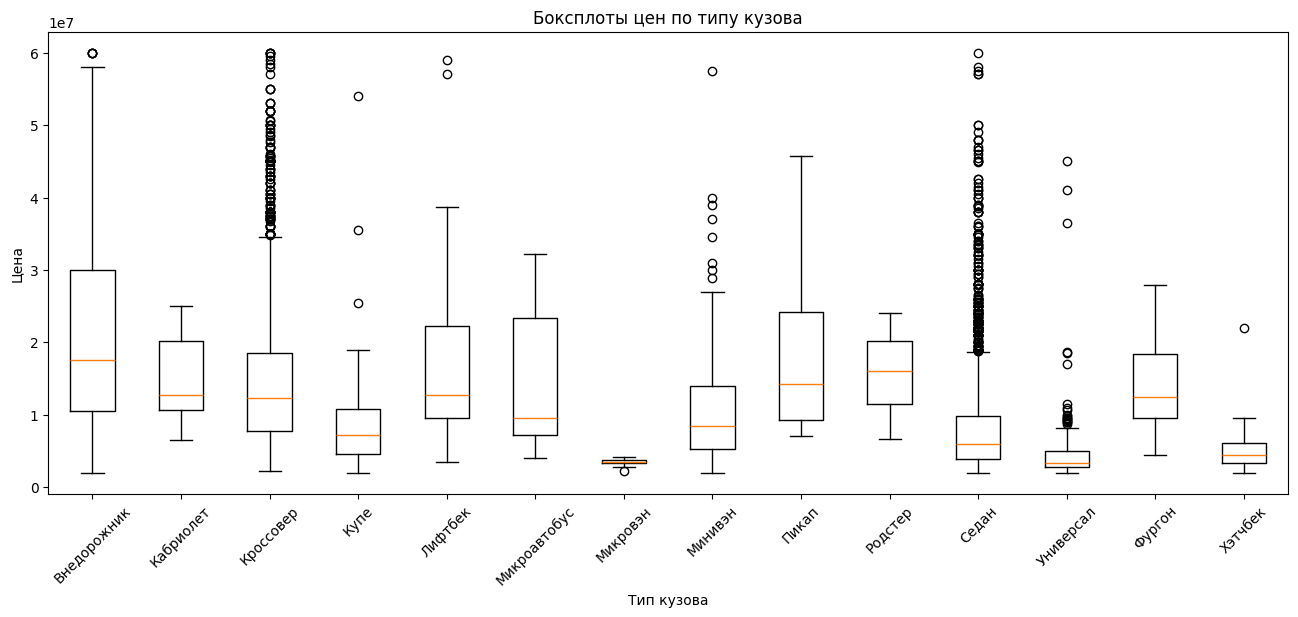

In [4476]:
body_types = sorted(df["body_type"].unique())

data = []

for i in body_types:
    q = df[df["body_type"] == i]["price"]
    data.append(q)

plt.figure(figsize=(16, 6))
plt.boxplot(data, labels=body_types)
plt.title("Боксплоты цен по типу кузова")
plt.xlabel("Тип кузова")
plt.ylabel("Цена")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3938/240920720.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=rasp)


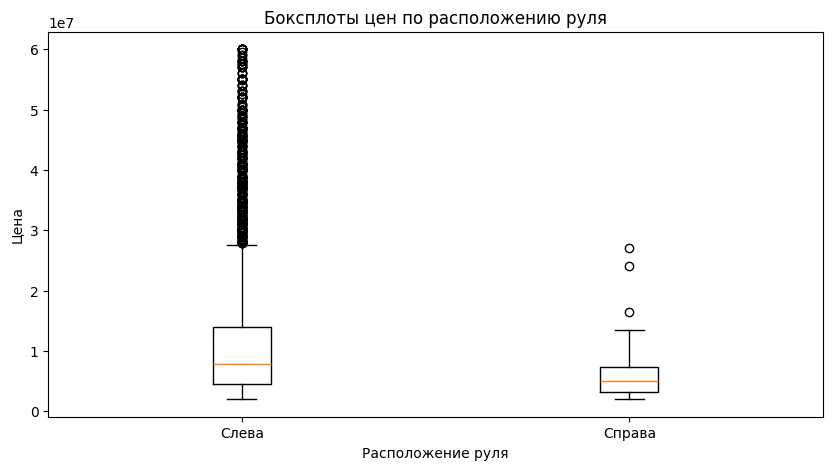

In [4477]:
rasp = sorted(df["steering_wheel"].unique())

data = []

for i in rasp:
    q = df[df["steering_wheel"] == i]["price"]
    data.append(q)

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=rasp)
plt.title("Боксплоты цен по расположению руля")
plt.xlabel("Расположение руля")
plt.ylabel("Цена")
plt.show()

/tmp/ipykernel_3938/4263745318.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=trans)


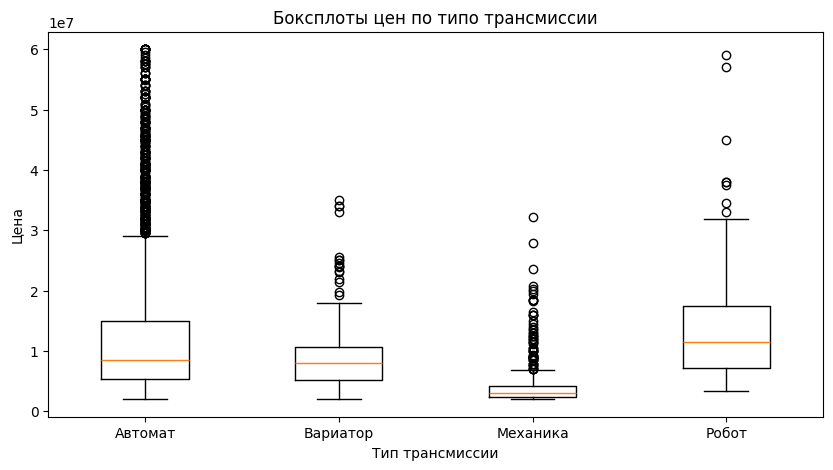

In [4478]:
trans = sorted(df["transmission"].unique())

data = []

for i in trans:
    q = df[df["transmission"] == i]["price"]
    data.append(q)

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=trans)
plt.title("Боксплоты цен по типо трансмиссии")
plt.xlabel("Тип трансмиссии")
plt.ylabel("Цена")
plt.show()

Как итог, price используем как исходный target и сохраняем для интерпретации результатов. Для обучения модели создаем target_log_price

In [4479]:
premium = ["BMW", "Lexus", "Mercedes-Benz", "Audi"]
df["is_premium"] = df["brand"].isin(premium).astype(int)

In [4480]:
df["is_premium"].value_counts()

,count
is_premium,
1,2661
0,2624


/tmp/ipykernel_3938/2217134518.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Не премиум", "Премиум"])


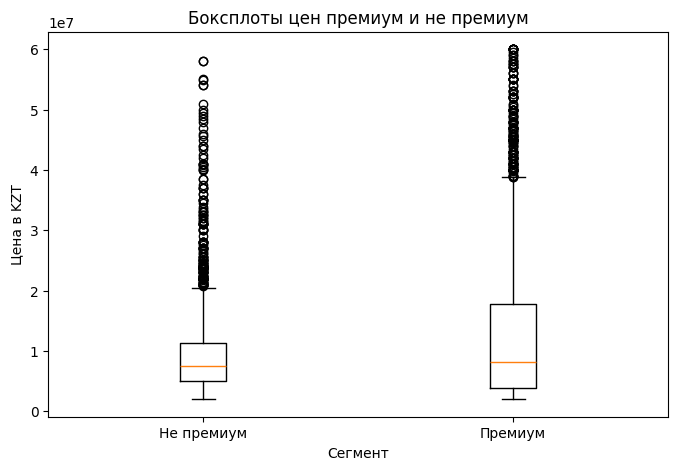

In [4481]:
data = [df[df["is_premium"] == 0]["price"], df[df["is_premium"] == 1]["price"]]

plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=["Не премиум", "Премиум"])
plt.title("Боксплоты цен премиум и не премиум")
plt.xlabel("Сегмент")
plt.ylabel("Цена в KZT")
plt.show()

Признак is_premium разделяет автомобили на премиальный и непремиальный сегменты. Группы почти равны по размеру: 2661 и 2624 объявления. По boxplot видно, что премиальный сегмент имеет более высокий верхний хвост цен. При этом медианы не отличаются, возможно потому что старые премиум авто полностью самортизировали свои стоимости

## 3. City

In [4482]:
df["city"] = df["city"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
city_split = df["city"].str.split(",", n=1, expand=True)
df["city_name"] = city_split[0].str.strip()
df["region"] = city_split[1].str.strip()

In [4483]:
df["city_name"].sort_values().unique()

array(['Абай (Абайский р-н)', 'Абай (Келесский р-н)',
       'Ават (Енбекшиказахский р-н)', 'Айтеке би',
       'Акколь (Аккольский р-н)', 'Аксай', 'Аксу', 'Аксукент', 'Актау',
       'Актобе', 'Актогай', 'Алматы', 'Алтай', 'Аральск', 'Аршалы',
       'Астана', 'Асыката', 'Атакент', 'Атбасар', 'Атырау', 'Аулиеколь',
       'Аягоз', 'Байконыр', 'Байтерек', 'Балхаш', 'Бауыржана Момышулы',
       'Бейнеу', 'Боралдай', 'Глубокое', 'Державинск',
       'Другой город в Китае', 'Есик', 'Есиль', 'Жаксы', 'Жалагаш',
       'Жанакорган', 'Жанаозен', 'Жанатас', 'Жаркент', 'Жезказган',
       'Железинка', 'Жетысай', 'Житикара', 'Иргели', 'Казалинск',
       'Кандыагаш', 'Карабалык (Карабалыкский р-н)', 'Карабулак',
       'Караганда', 'Каратобе', 'Каргалы', 'Каркаралинск', 'Каскелен',
       'Кентау', 'Киевка', 'Кишкенеколь', 'Кокшетау', 'Конаев (Капшагай)',
       'Кордай', 'Костанай', 'Кулан', 'Кульсары', 'Кызылорда', 'Ленгер',
       'Лисаковск', 'Мангистау', 'Махамбет', 'Мерке', 'Мойынкум',
  

In [4484]:
df["region"].sort_values().unique()

array(['0', 'Абайская область', 'Акмолинская область',
       'Актюбинская область', 'Алматинская область', 'Атырауская область',
       'Восточно-Казахстанская область', 'Жамбылская область',
       'Жетысуская область', 'Западно-Казахстанская область',
       'Карагандинская область', 'Китай', 'Костанайская область',
       'Кызылординская область', 'Мангистауская область',
       'Павлодарская область', 'Северо-Казахстанская область',
       'Туркестанская область', 'Улытауская область'], dtype=object)

Китай и 0 вряд ли регионы Казахстана, давайте их обработаем.

In [4485]:
df[df["region"].isin(["Китай", "0"])]

,brand,model,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,...,g_is_current,g_number,g_is_restyling,g_age_car_release,g_span,generation_number_missing,target_log_price,is_premium,city_name,region
612,BMW,X5 M,2020,"Алматы, 0",Кроссовер,бензин,4.4,74044,Автомат,Полный привод,...,1.0,0.0,0.0,1.0,7.0,1,17.661394,1,Алматы,0
2484,Lexus,RX 300,2001,"Астана, 0",Кроссовер,бензин,3.0,287400,Автомат,Полный привод,...,0.0,1.0,0.0,4.0,6.0,0,15.414898,1,Астана,0
3081,Toyota,Estima,2007,"Астана, 0",Минивэн,бензин,2.4,282882,Вариатор,Передний привод,...,0.0,3.0,0.0,1.0,2.0,0,15.454507,0,Астана,0
4398,Mercedes-Benz,V 250,2018,"Другой город в Китае, Китай",Минивэн,бензин,2.0,60000,Автомат,Задний привод,...,1.0,0.0,0.0,4.0,12.0,1,17.179075,1,Другой город в Китае,Китай


Руками исправим баг парсера.

In [4486]:
df.loc[612, "city_name"] = "Алматы"
df.loc[612, "region"] = "Алматинская область"
df.loc[612, "city"] = "Алматы, Алматинская область"

df.loc[[2484, 3081], "city_name"] = "Астана"
df.loc[[2484, 3081], "region"] = "Акмолинская область"
df.loc[[2484, 3081], "city"] = "Астана, Акмолинская область"

df = df.drop(index=4398).copy()

Уникальных city: 109

Уникальных city_name: 109

Уникальных region: 17

Все отилчно, в Казахстане реально 17 обсластей и все 109 городов реальны.

In [4487]:
print(df["city"].nunique())
print(df["city_name"].nunique())
print(df["region"].nunique())

display(df["city_name"].value_counts().head(20))
display(df["region"].value_counts().head(20))

109
109
17


,count
city_name,
Алматы,1854
Астана,856
Шымкент,542
Караганда,256
Актобе,184
Актау,171
Атырау,156
Тараз,133
Костанай,130


,count
region,
Алматинская область,1883
Акмолинская область,936
Туркестанская область,624
Карагандинская область,280
Мангистауская область,212
Актюбинская область,187
Атырауская область,162
Жамбылская область,161
Костанайская область,157


Тк скорость и цена продажи оыбчно зависит от размера локального рынка, то нам стоит сделать градачию городов.

In [4488]:
tier_1 = {"Алматы", "Астана"}
tier_2 = {"Шымкент"}

# https://ru.wikipedia.org/wiki/%D0%90%D0%B4%D0%BC%D0%B8%D0%BD%D0%B8%D1%81%D1%82%D1%80%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D0%BE%D0%B5_%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D0%9A%D0%B0%D0%B7%D0%B0%D1%85%D1%81%D1%82%D0%B0%D0%BD%D0%B0
reg_centr = {"Караганда", "Актобе", "Актау", "Атырау", "Тараз", "Костанай", "Павлодар", "Уральск", "Усть-Каменогорск", "Кызылорда", "Петропавловск", "Семей", "Кокшетау", "Талдыкорган", "Туркестан"}

df["city_tier"] = "other_city"

for city in tier_1:
    df.loc[df["city_name"] == city, "city_tier"] = "tier_1"
for city in tier_2:
    df.loc[df["city_name"] == city, "city_tier"] = "tier_2"
for city in reg_centr:
    df.loc[df["city_name"] == city, "city_tier"] = "regional_center"

df["is_big_city"] = df["city_name"].isin(tier_1 | tier_2).astype(int)

df.head()

,brand,model,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,...,g_is_restyling,g_age_car_release,g_span,generation_number_missing,target_log_price,is_premium,city_name,region,city_tier,is_big_city
0,Chevrolet,Cobalt,2021,"Астана, Акмолинская область",Седан,бензин,1.5,145113,Автомат,Передний привод,...,0.0,10.0,15.0,0,15.317363,0,Астана,Акмолинская область,tier_1,1
1,Chevrolet,Monza,2023,"Астана, Акмолинская область",Седан,бензин,1.5,20000,Робот,Передний привод,...,1.0,1.0,4.0,0,15.671809,0,Астана,Акмолинская область,tier_1,1
2,Chevrolet,Captiva,2021,"Алматы, Алматинская область",Внедорожник,бензин,1.5,85024,Автомат,Передний привод,...,0.0,3.0,8.0,0,15.782623,0,Алматы,Алматинская область,tier_1,1
3,Chevrolet,Cruze,2013,"Алматы, Алматинская область",Хэтчбек,бензин,1.8,146000,Автомат,Передний привод,...,1.0,1.0,3.0,1,15.297115,0,Алматы,Алматинская область,tier_1,1
4,Chevrolet,Aveo,2007,"Астана, Акмолинская область",Седан,бензин,1.4,216000,Автомат,Передний привод,...,1.0,1.0,6.0,1,14.711599,0,Астана,Акмолинская область,tier_1,1


In [4489]:
df = df.reset_index(drop=True)

In [4490]:
print(df["city_tier"].value_counts())
print(df["is_big_city"].value_counts())

city_tier
tier_1             2710
regional_center    1715
tier_2              542
other_city          317
Name: count, dtype: int64
is_big_city
1    3252
0    2032
Name: count, dtype: int64


/tmp/ipykernel_3938/513106692.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Не большой", "Большой"])


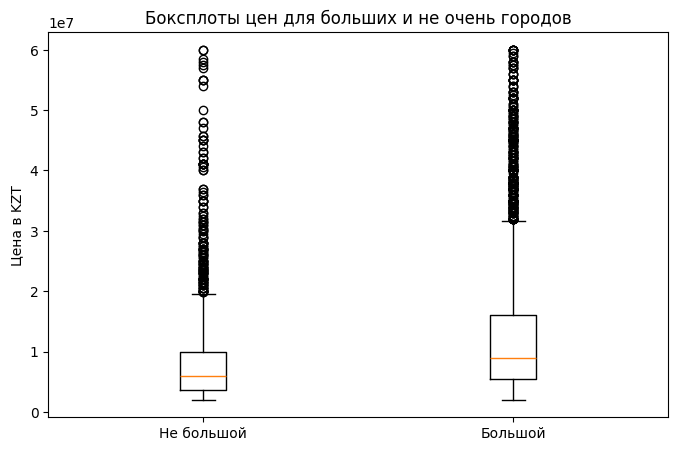

In [4491]:
data = [df[df["is_big_city"] == 0]["price"], df[df["is_big_city"] == 1]["price"]]

plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=["Не большой", "Большой"])
plt.title("Боксплоты цен для больших и не очень городов")
plt.ylabel("Цена в KZT")
plt.show()

/tmp/ipykernel_3938/3788150031.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=df["city_tier"].unique())


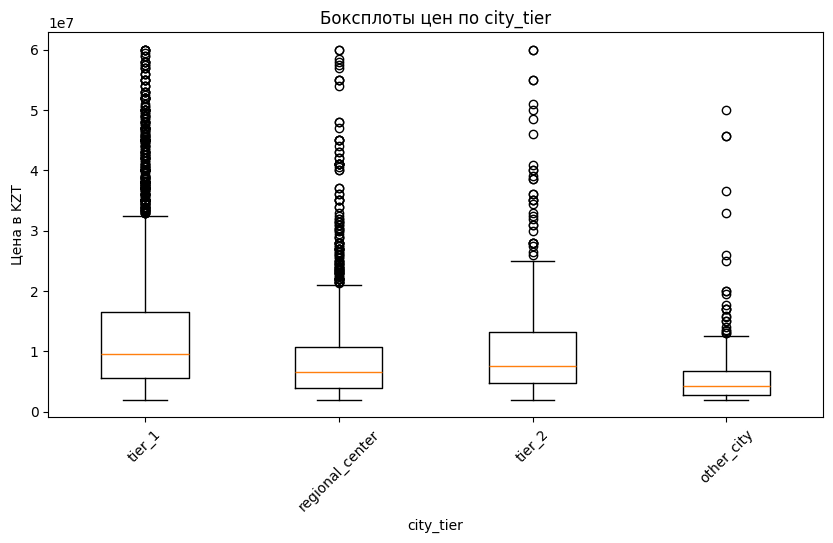

In [4492]:

data = []

for i in df["city_tier"].unique():
    q = df[df["city_tier"] == i]["price"]
    data.append(q)

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=df["city_tier"].unique())
plt.title("Боксплоты цен по city_tier")
plt.xlabel("city_tier")
plt.ylabel("Цена в KZT")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3938/596741019.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_cities)


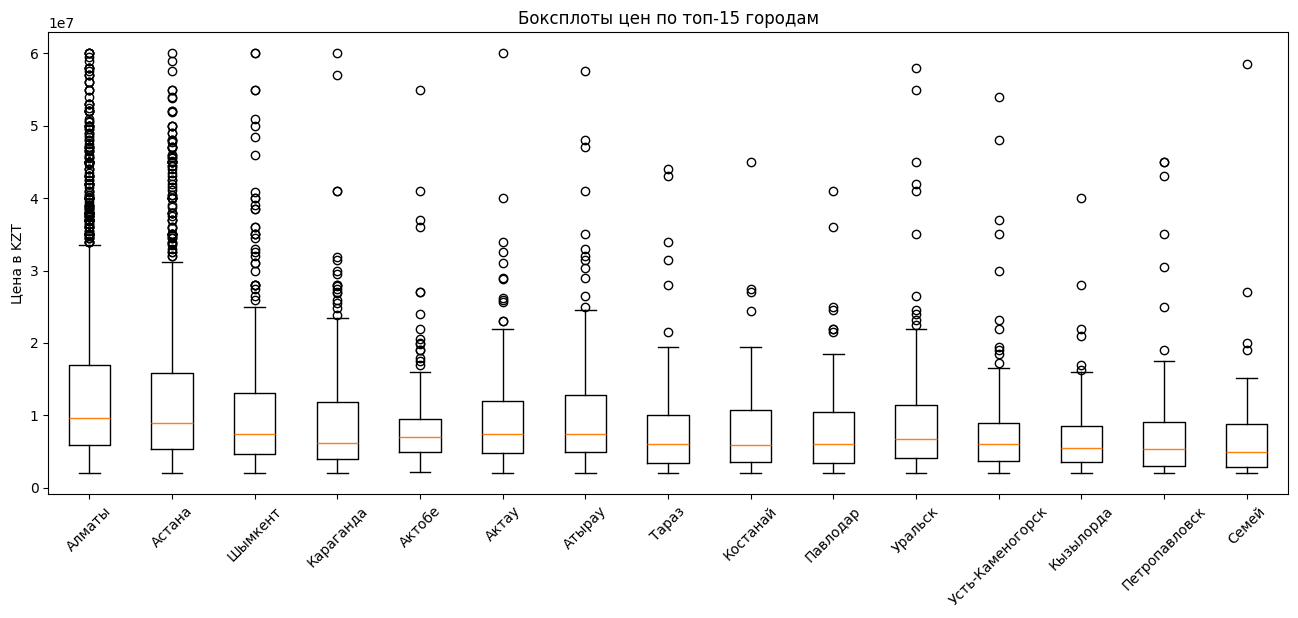

In [4493]:
top_cities = df["city_name"].value_counts().head(15).index

data = []

for i in top_cities:
    q = df[df["city_name"] == i]["price"]
    data.append(q)

plt.figure(figsize=(16, 6))
plt.boxplot(data, labels=top_cities)
plt.title("Боксплоты цен по топ-15 городам")
plt.ylabel("Цена в KZT")
plt.xticks(rotation=45)
plt.show()

Изначально city содержит город и регион, поэтому мы разделили его на city_name и region. После разделения были найдены: 0 и Китай. 3 строки были исправлены, 1 строка с городом в Китае удалена

После очистки добавили признаки city_tier и is_big_city, чтобы выделить крупнейшие рынки: Алматы, Астану и Шымкент

In [4494]:
df.groupby("is_big_city")["price"].agg(["count", "mean", "median", "min", "max"])

/usr/local/lib/python3.12/dist-packages/IPython/core/displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,count,mean,median,min,max
is_big_city,,,,,
0,2032,8.469079e+06,6000000.0,2000000,60000000
1,3252,1.307148e+07,9000000.0,2000000,60000000


In [4495]:
df.groupby("city_tier")["price"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
city_tier,,,,,
other_city,317,6.018651e+06,4300000.0,2000000,50000000
regional_center,1715,8.922015e+06,6500000.0,2000000,60000000
tier_1,2710,1.360463e+07,9500000.0,2000000,60000000
tier_2,542,1.040573e+07,7500000.0,2000000,60000000


In [4496]:
city_counts = df["city_name"].value_counts()

print(city_counts.shape[0])
print((city_counts < 10).sum())
print(city_counts[city_counts < 10].sum())

109
82
188


* Городов всего: 109
* Городов с < 10 объявлениями: 82
* Строк в городах с < 10 объявлениями: 188

По признаку is_big_city видно, что объявления из крупных городов дороже, н-мер медиана в Алматы, Астане и Шымкенте составляет около 9 млн KZT, в остальных городах - около 6 млн KZT. Средняя цена также выше в крупных городах: 13.1 млн против 8.5 млн KZT

Самая высокая медиан у tier_1 городов - Алматы и Астаны 9.5 млн KZT. Далее в tier_2 7.5 млн KZT. Рег центры по 6.5 млн KZT, а остальные города - около 4.3 млн KZT. Это подтверждает, что размер и ликвидность локального рынка связаны с ценой автомобиля

## 4. Engine_volume

In [4497]:
df[df["engine_volume"] == 0]

,brand,model,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,...,g_is_restyling,g_age_car_release,g_span,generation_number_missing,target_log_price,is_premium,city_name,region,city_tier,is_big_city
245,Audi,e-tron Sportback,2020,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,70000,Автомат,Полный привод,...,0.0,1.0,7.0,0,17.182806,1,Алматы,Алматинская область,tier_1,1
253,Audi,e-tron,2019,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,34000,Автомат,Полный привод,...,0.0,1.0,8.0,0,16.588099,1,Алматы,Алматинская область,tier_1,1
271,Audi,e-tron Sportback,2021,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,32285,Автомат,Полный привод,...,0.0,2.0,7.0,0,16.906553,1,Алматы,Алматинская область,tier_1,1
593,BMW,i3,2023,"Астана, Акмолинская область",Седан,Электрический\n,0.0,18500,Автомат,Задний привод,...,0.0,1.0,4.0,1,16.705882,1,Астана,Акмолинская область,tier_1,1
602,BMW,i5,2024,"Алматы, Алматинская область",Седан,Электрический\n,0.0,10000,Автомат,Полный привод,...,0.0,1.0,3.0,0,17.479072,1,Алматы,Алматинская область,tier_1,1
872,Audi,e-tron Sportback,2020,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,42000,Автомат,Полный привод,...,0.0,1.0,7.0,0,17.216708,1,Алматы,Алматинская область,tier_1,1
904,Audi,Q8 e-tron,2024,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,350,Автомат,Полный привод,...,0.0,2.0,4.0,0,17.453097,1,Алматы,Алматинская область,tier_1,1
1074,Kia,K3,2021,"Шымкент, Туркестанская область",Седан,Электрический\n,0.0,98399,Автомат,Передний привод,...,1.0,0.0,5.0,0,15.448665,0,Шымкент,Туркестанская область,tier_2,1
1145,BMW,iX1,2025,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,20,Автомат,Передний привод,...,0.0,3.0,4.0,0,16.733281,1,Алматы,Алматинская область,tier_1,1
1166,BMW,iX,2023,"Алматы, Алматинская область",Кроссовер,Электрический\n,0.0,22000,Автомат,Полный привод,...,0.0,2.0,5.0,0,17.426428,1,Алматы,Алматинская область,tier_1,1


In [4498]:
df["fuel_type"] = df["fuel_type"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["is_electric"] = (df["fuel_type"] == "Электрический").astype(int)

engine_volume = 0 это электромобили. Поэтому такие значения не считаем ошибкой и не удаляем. ДДобовляем бинарный признак is_electric

/tmp/ipykernel_3938/364105005.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Не электро", "Электро"])


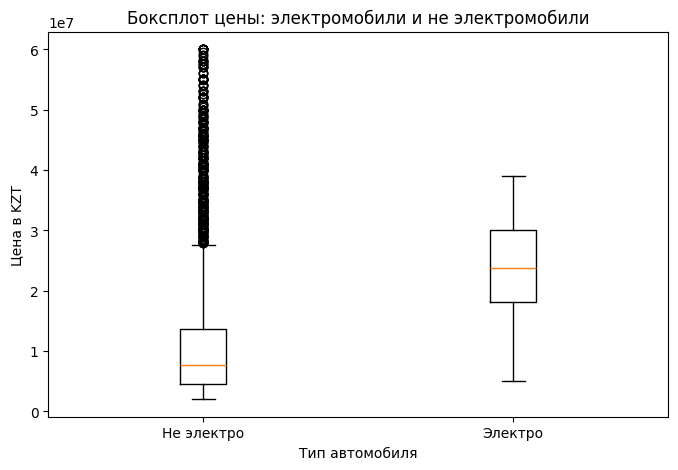

In [4499]:
data = [df[df["is_electric"] == 0]["price"], df[df["is_electric"] == 1]["price"]]

plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=["Не электро", "Электро"])

plt.title("Боксплот цены: электромобили и не электромобили")
plt.xlabel("Тип автомобиля")
plt.ylabel("Цена в KZT")
plt.show()

In [4500]:
df.groupby("is_electric")["price"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
is_electric,,,,,
0,5262,1.125032e+07,7700000.0,2000000,60000000
1,22,2.356591e+07,23700000.0,5000000,39000000


Всего 22 электромобиля из 5262 автомобилей. При этом цены на них выше, медиана для электромобилей составляет 23.7 млн KZT, а для обычных автомобилей 7.7 млн KZT. Поэтому is_electric полезен для модели

In [4501]:
df["engine_volume"].describe()

,engine_volume
count,5284.000000
mean,2.620931
std,1.034117
min,0.000000
25%,2.000000
50%,2.500000
75%,3.000000
max,8.000000


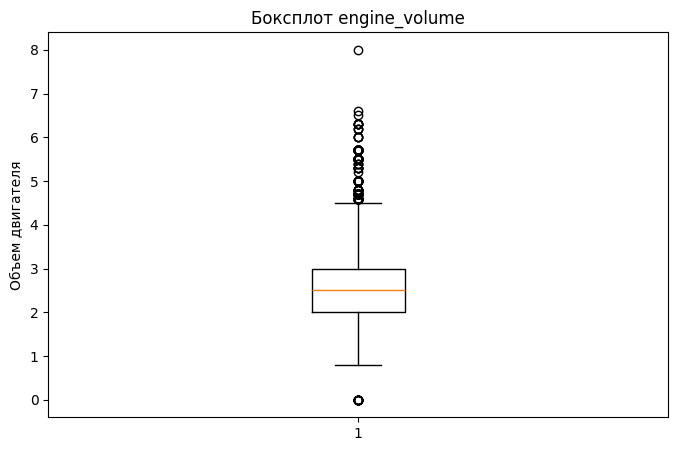

In [4502]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["engine_volume"])
plt.title("Боксплот engine_volume")
plt.ylabel("Объем двигателя")
plt.show()

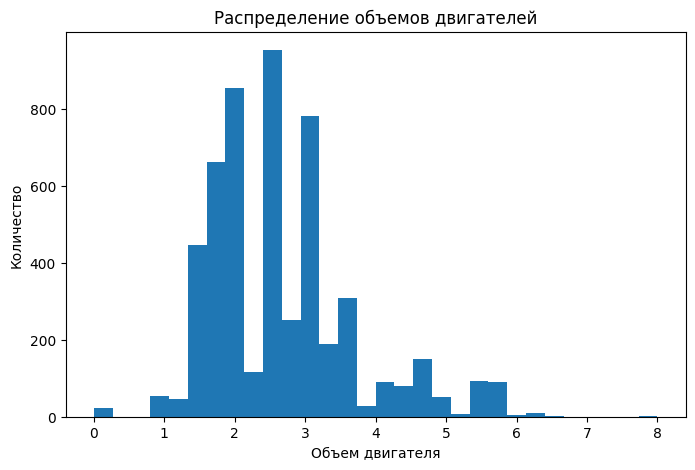

In [4503]:
plt.figure(figsize=(8, 5))
plt.hist(df["engine_volume"], bins=30)
plt.title("Распределение объемов двигателей")
plt.xlabel("Объем двигателя")
plt.ylabel("Количество")
plt.show()

In [4504]:
df[df["is_electric"] == 0]["engine_volume"].describe()

,engine_volume
count,5262.000000
mean,2.631889
std,1.022264
min,0.800000
25%,2.000000
50%,2.500000
75%,3.000000
max,8.000000


In [4505]:
df[df["engine_volume"] > 6]

,brand,model,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,...,g_age_car_release,g_span,generation_number_missing,target_log_price,is_premium,city_name,region,city_tier,is_big_city,is_electric
28,Chevrolet,Tahoe,2026,"Алматы, Алматинская область",Внедорожник,бензин,6.2,33,Автомат,Полный привод,...,2.0,2.0,0,17.875954,0,Алматы,Алматинская область,tier_1,1,0
677,Audi,A8,2011,"Алматы, Алматинская область",Седан,бензин,6.3,109000,Автомат,Полный привод,...,2.0,5.0,0,16.522894,1,Алматы,Алматинская область,tier_1,1,0
829,Kia,K5,2010,"Алматы, Алматинская область",Седан,бензин,8.0,179000,Автомат,Передний привод,...,0.0,3.0,0,15.869634,0,Алматы,Алматинская область,tier_1,1,0
1571,Chevrolet,Camaro,2010,"Астана, Акмолинская область",Купе,бензин,6.2,40000,Автомат,Задний привод,...,1.0,4.0,0,16.754084,0,Астана,Акмолинская область,tier_1,1,0
1814,Chevrolet,Tahoe,2022,"Актобе, Актюбинская область",Внедорожник,бензин,6.2,70000,Автомат,Полный привод,...,3.0,7.0,0,17.529083,0,Актобе,Актюбинская область,regional_center,0,0
3478,BMW,M760,2016,"Алматы, Алматинская область",Седан,бензин,6.6,58000,Автомат,Полный привод,...,1.0,4.0,1,17.073607,1,Алматы,Алматинская область,tier_1,1,0
3608,Audi,A8,2012,"Астана, Акмолинская область",Седан,бензин,6.3,163000,Автомат,Полный привод,...,3.0,5.0,0,16.454568,1,Астана,Акмолинская область,tier_1,1,0
3904,Mercedes-Benz,ML 63 AMG,2006,"Астана, Акмолинская область",Внедорожник,бензин,6.3,134000,Автомат,Полный привод,...,1.0,3.0,1,16.380460,1,Астана,Акмолинская область,tier_1,1,0
4240,Mercedes-Benz,ML 63 AMG,2005,"Алматы, Алматинская область",Внедорожник,бензин,6.3,218000,Автомат,Полный привод,...,0.0,3.0,1,15.687313,1,Алматы,Алматинская область,tier_1,1,0
4241,Mercedes-Benz,S 63 AMG,2007,"Шымкент, Туркестанская область",Седан,бензин,6.3,200000,Автомат,Задний привод,...,2.0,4.0,1,16.300417,1,Шымкент,Туркестанская область,tier_2,1,0


Большинство автомобилей имеют объем двигателя от 1.5 до 3.0 литров, медиана равна 2.5 литра. Значение 0 относится к электромобилям, сделали признаком is_electric. Значения выше 6 л - это рельаные данные

## 5. Year

In [4506]:
df["year"].describe()

,year
count,5284.000000
mean,2012.547123
std,9.288703
min,1977.000000
25%,2006.000000
50%,2014.000000
75%,2021.000000
max,2026.000000


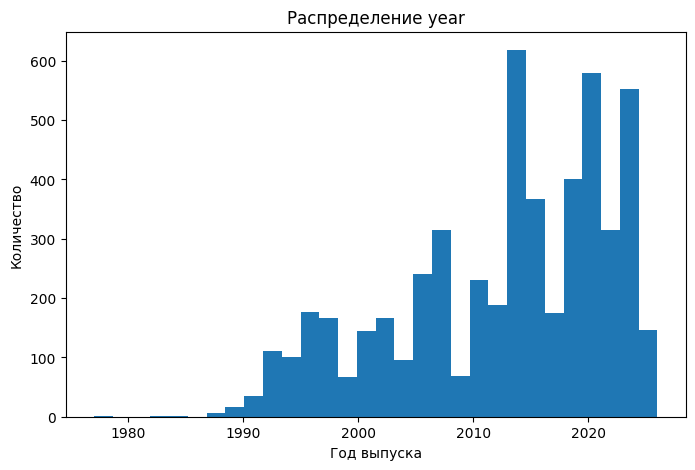

In [4507]:
plt.figure(figsize=(8, 5))
plt.hist(df["year"], bins=30)
plt.title("Распределение year")
plt.xlabel("Год выпуска")
plt.ylabel("Количество")
plt.show()

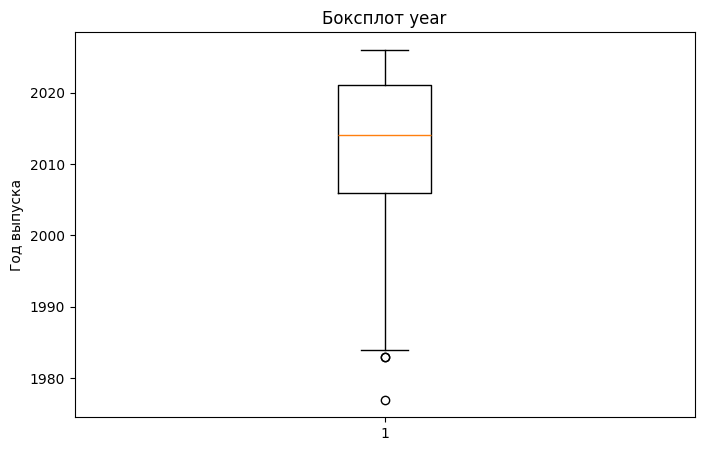

In [4508]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["year"])
plt.title("Боксплот year")
plt.ylabel("Год выпуска")
plt.show()

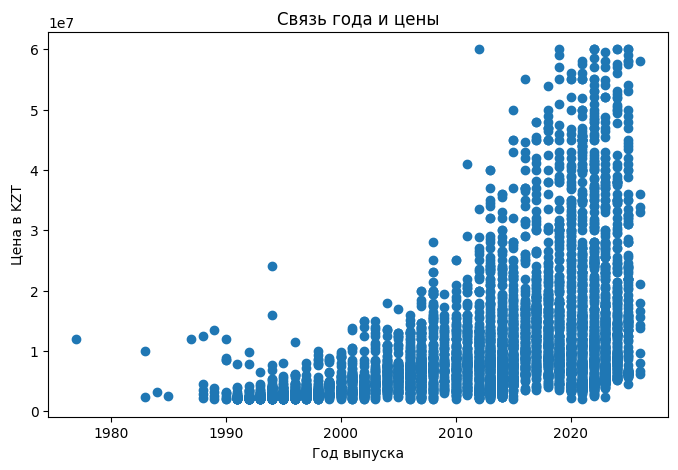

In [4509]:
plt.figure(figsize=(8, 5))
plt.scatter(df["year"], df["price"])
plt.title("Связь года и цены")
plt.xlabel("Год выпуска")
plt.ylabel("Цена в KZT")
plt.show()

In [4510]:
now = 2026

df["car_age"] = now - df["year"]

In [4511]:
df["is_new_car"] = 0
df.loc[df["car_age"] <= 1, "is_new_car"] = 1

df["is_recent_car"] = 0
df.loc[df["car_age"] <= 3, "is_recent_car"] = 1

df["is_old_car"] = 0
df.loc[df["car_age"] >= 15, "is_old_car"] = 1

In [4512]:
df["age_bucket"] = "20_plus"

df.loc[df["car_age"] <= 20, "age_bucket"] = "13_20"
df.loc[df["car_age"] <= 12, "age_bucket"] = "8_12"
df.loc[df["car_age"] <= 7,  "age_bucket"] = "4_7"
df.loc[df["car_age"] <= 3,  "age_bucket"] = "2_3"
df.loc[df["car_age"] <= 1,  "age_bucket"] = "0_1"

In [4513]:
df[["year", "car_age", "is_new_car", "is_recent_car", "is_old_car", "age_bucket"]].head()

,year,car_age,is_new_car,is_recent_car,is_old_car,age_bucket
0,2021,5,0,0,0,4_7
1,2023,3,0,1,0,2_3
2,2021,5,0,0,0,4_7
3,2013,13,0,0,0,13_20
4,2007,19,0,0,1,13_20


In [4514]:
df[["year", "car_age"]].describe()

,year,car_age
count,5284.000000,5284.000000
mean,2012.547123,13.452877
std,9.288703,9.288703
min,1977.000000,0.000000
25%,2006.000000,5.000000
50%,2014.000000,12.000000
75%,2021.000000,20.000000
max,2026.000000,49.000000


In [4515]:
print(df["is_new_car"].value_counts())
print(df["is_recent_car"].value_counts())
print(df["is_old_car"].value_counts())
print(df["age_bucket"].value_counts())

is_new_car
0    5138
1     146
Name: count, dtype: int64
is_recent_car
0    4586
1     698
Name: count, dtype: int64
is_old_car
0    3339
1    1945
Name: count, dtype: int64
age_bucket
13_20      1208
20_plus    1190
4_7        1106
8_12       1082
2_3         552
0_1         146
Name: count, dtype: int64


In [4516]:
df.groupby("age_bucket")["price"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
age_bucket,,,,,
0_1,146,2.142525e+07,15995000.0,4500000,60000000
13_20,1208,8.772711e+06,7500000.0,2000000,60000000
20_plus,1190,4.206379e+06,3316666.5,2000000,24000000
2_3,552,1.585907e+07,11400000.0,2300000,60000000
4_7,1106,1.670597e+07,11645000.0,2000000,60000000
8_12,1082,1.271304e+07,10375000.0,2000000,55000000


/tmp/ipykernel_3938/2691868958.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=age_bucket)


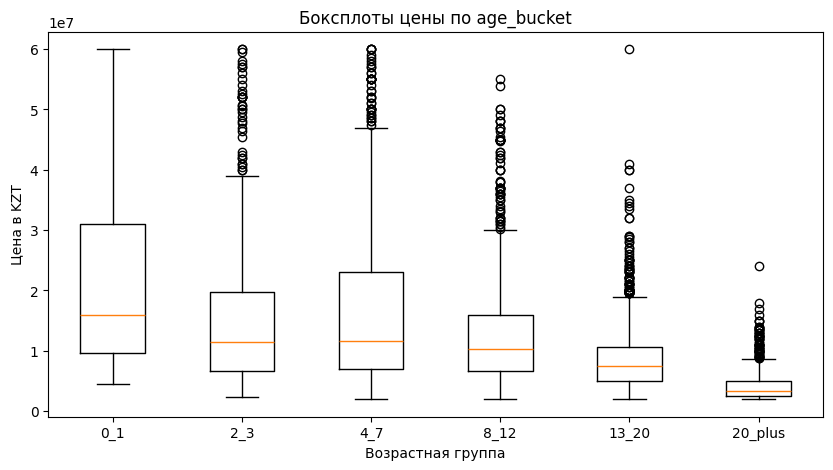

In [4517]:
age_bucket = ["0_1", "2_3", "4_7", "8_12", "13_20", "20_plus"]

data = []

for i in age_bucket:
    q = df[df["age_bucket"] == i]["price"]
    data.append(q)

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=age_bucket)
plt.title("Боксплоты цены по age_bucket")
plt.xlabel("Возрастная группа")
plt.ylabel("Цена в KZT")
plt.show()

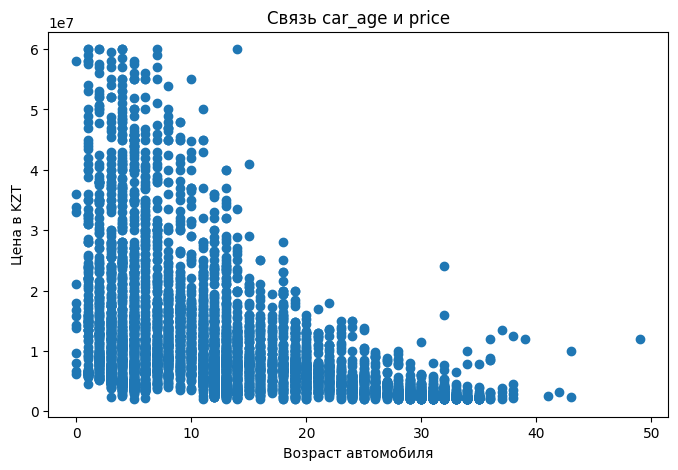

In [4518]:
plt.figure(figsize=(8, 5))
plt.scatter(df["car_age"], df["price"])

plt.title("Связь car_age и price")
plt.xlabel("Возраст автомобиля")
plt.ylabel("Цена в KZT")
plt.show()

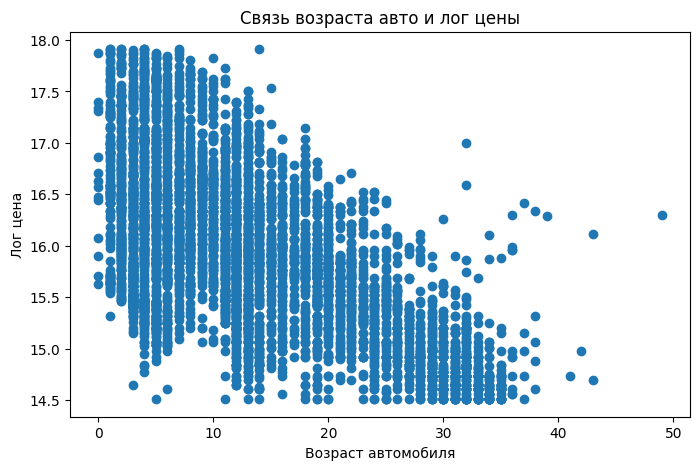

In [4519]:
plt.figure(figsize=(8, 5))
plt.scatter(df["car_age"], df["target_log_price"])

plt.title("Связь возраста авто и лог цены")
plt.xlabel("Возраст автомобиля")
plt.ylabel("Лог цена")
plt.show()

Признак year не имеет пропусков, от 1977, больше 2026 нет. Для модели дополнительно создан car_age. Также добавлены флаги is_new_car, is_recent_car, is_old_car и категориальный признак age_bucket. Анализ по age_bucket показывает, что новые автомобили имеют выше медианную цену, с другой стороны машины старше 20 лет заметно дешевле

## 6. Color

In [4520]:
df["color"].value_counts()

,count
color,
unknown,1404
белый,653
черный металлик,540
белый металлик,508
серебристый металлик,395
черный,392
серый металлик,286
серый,224
синий металлик,189


In [4521]:
print(df["color"].nunique())
print(df["color"].isna().sum())

40
0


color (40 уникальных значений и 0 пропусков) содержит две части цвета: цвет и  пометку металлик. Серый и серый металлик не являются разными цветами, таким образом мы можем снизить размерность. Можно выделить цвет отдельно, а металлик сохранить в бин признаке. Также в данных много значений unknown, поэтому добавим отдельный признак color_known

In [4522]:
df["color_clean"] = df["color"].astype(str).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

In [4523]:
df["is_metallic"] = 0
df.loc[df["color_clean"].str.contains("металлик", na=False), "is_metallic"] = 1

In [4524]:
df["base_color"] = (df["color_clean"].str.replace(r"\s*металлик\s*", "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip())
df.loc[df["base_color"] == "", "base_color"] = "unknown"

In [4525]:
print(df["color"].nunique())
print(df["base_color"].nunique())
print((df["color_clean"] == "unknown").sum())
print((df["base_color"] == "unknown").sum())

40
21
1404
1404


Уникальных цветов: 40

Уникальных базовых цветов: 21

unknown в изначальном цвете: 1404

unknown в базовых цветах: 1404

In [4526]:
df["color_known"] = 1
df.loc[df["base_color"] == "unknown", "color_known"] = 0

In [4527]:
df["base_color"].value_counts()

,count
base_color,
unknown,1404
белый,1161
черный,932
серебристый,566
серый,510
синий,296
зеленый,105
коричневый,57
бордовый,41


In [4528]:
df["is_metallic"].value_counts()

,count
is_metallic,
0,3119
1,2165


После обработки base_color не содержит металлик. Количество цветов стало меньше, а информация о металлике сохранена отдельно

In [4529]:
df["color_known"].value_counts()

,count
color_known,
1,3880
0,1404


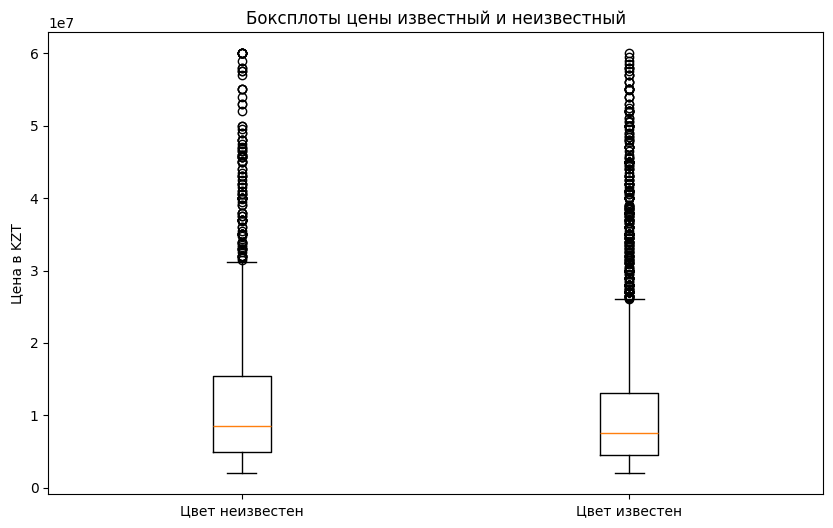

In [4530]:
data = [df[df["color_known"] == 0]["price"], df[df["color_known"] == 1]["price"]]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=["Цвет неизвестен", "Цвет известен"])

plt.title("Боксплоты цены известный и неизвестный")
plt.ylabel("Цена в KZT")
plt.show()

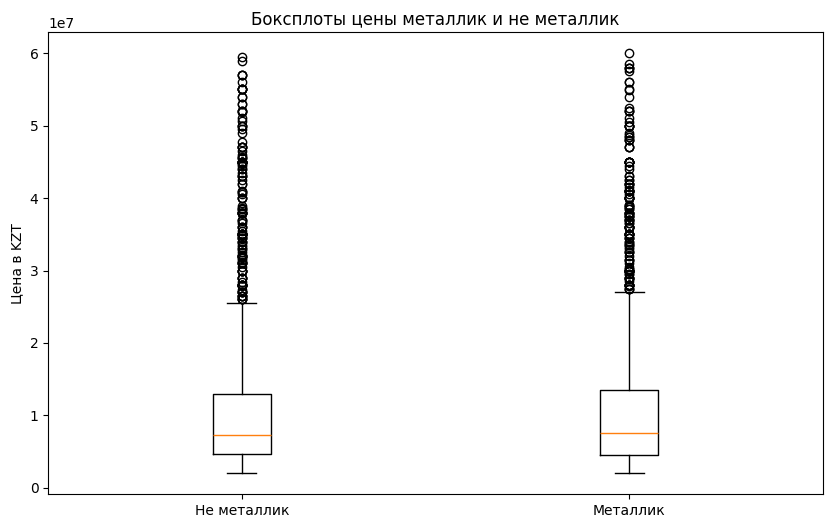

In [4531]:
data = [df[(df["color_known"] == 1) & (df["is_metallic"] == 0)]["price"], df[(df["color_known"] == 1) & (df["is_metallic"] == 1)]["price"]]
plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=["Не металлик", "Металлик"])
plt.title("Боксплоты цены металлик и не металлик")
plt.ylabel("Цена в KZT")
plt.show()

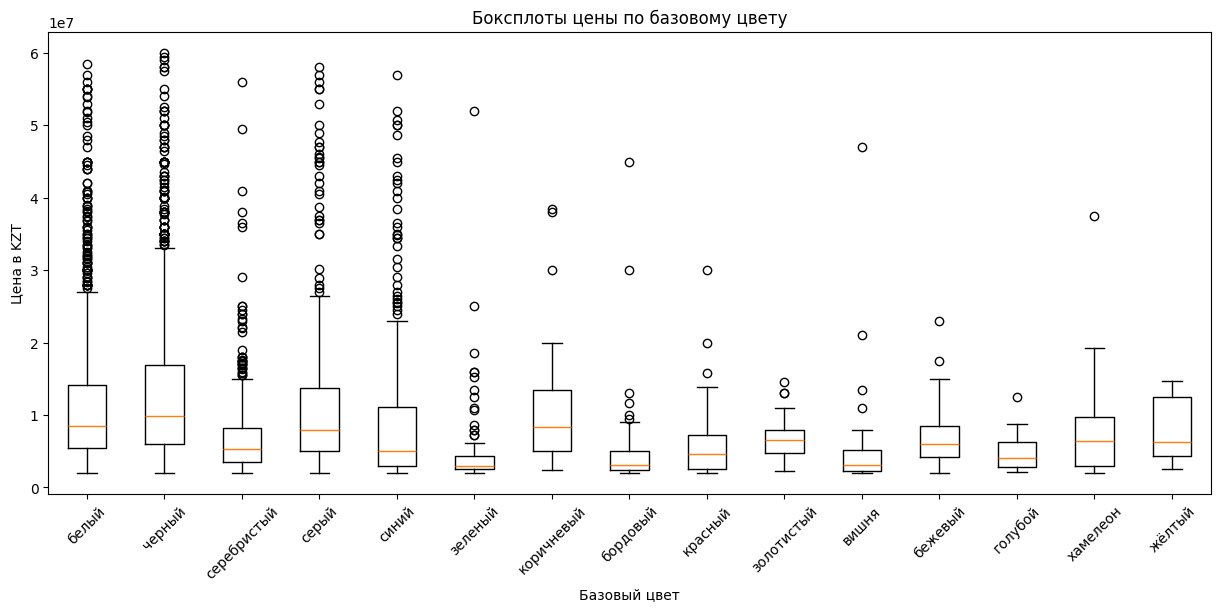

In [4532]:
cs = df[df["base_color"] != "unknown"]["base_color"].value_counts().head(15).index

data = []

for i in cs:
    q = df[df["base_color"] == i]["price"]
    data.append(q)

plt.figure(figsize=(15, 6))
plt.boxplot(data, tick_labels=cs)
plt.title("Боксплоты цены по базовому цвету")
plt.xlabel("Базовый цвет")
plt.ylabel("Цена в KZT")
plt.xticks(rotation=45)
plt.show()

In [4533]:
df = df.drop(columns=["color", "color_clean"])

color был разделен на base_color и is_metallic. Так мы снииз разменость, не теряя информацию о наличии металлика.

Тк в данных много unknown, дополнительно создан признак color_known, который показывает, известен ли цвет автомобиля

## 7. kz_registration

In [4534]:
df["kz_registration"].value_counts()

,count
kz_registration,
Да,5198
Нет,86


In [4535]:
df["kz_registration"] = df["kz_registration"].replace({"Да": 1, "Нет": 0})

/tmp/ipykernel_3938/3845145427.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["kz_registration"] = df["kz_registration"].replace({"Да": 1, "Нет": 0})


In [4536]:
df["kz_registration"].value_counts()

,count
kz_registration,
1,5198
0,86


In [4537]:
df["kz_registration"] = df["kz_registration"].astype(int)

Признак kz_registration содержит только два значения: Да и Нет, поэтому заменили их на 1 и 0 соответственно

## 8. Mileage

In [4538]:
df["mileage"].describe()

,mileage
count,5284.000000
mean,174573.563399
std,123657.062539
min,1.000000
25%,80000.000000
50%,152000.000000
75%,248000.000000
max,999999.000000


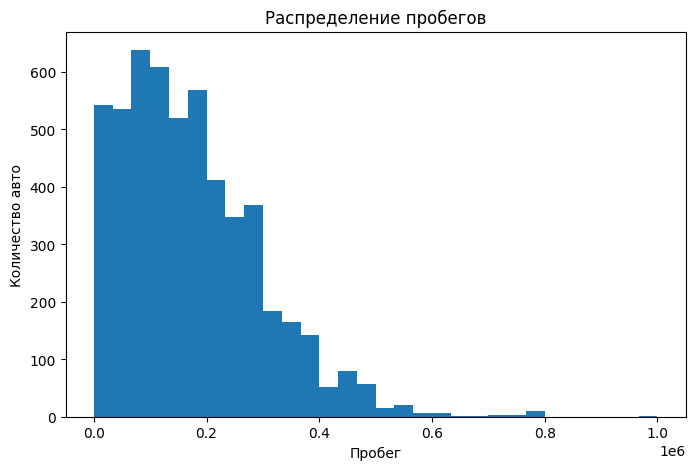

In [4539]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"], bins=30)
plt.title("Распределение пробегов")
plt.xlabel("Пробег")
plt.ylabel("Количество авто")
plt.show()

In [4540]:
df["log_mileage"] = np.log1p(df["mileage"])

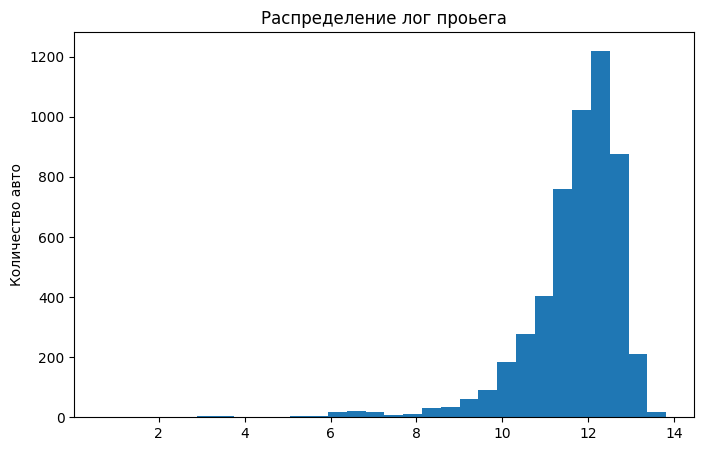

In [4541]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_mileage"], bins=30)
plt.title("Распределение лог проьега")
plt.ylabel("Количество авто")
plt.show()

In [4542]:
df["mileage_per_year"] = df["mileage"] / df["car_age"].clip(lower=1) # clip(lower=1) - заменяет 0 на 1, чтобы не было ошибки деления для авто у которых возраст меньше года
df["log_mileage_per_year"] = np.log1p(df["mileage_per_year"])

In [4543]:
df[["mileage", "log_mileage", "car_age", "mileage_per_year", "log_mileage_per_year"]].describe()

,mileage,log_mileage,car_age,mileage_per_year,log_mileage_per_year
count,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000
mean,174573.563399,11.676967,13.452877,14775.782918,9.378639
std,123657.062539,1.195646,9.288703,8024.131995,0.956622
min,1.000000,0.693147,0.000000,1.000000,0.693147
25%,80000.000000,11.289794,5.000000,10000.000000,9.210440
50%,152000.000000,11.931642,12.000000,13750.000000,9.528867
75%,248000.000000,12.421188,20.000000,18333.333333,9.816531
max,999999.000000,13.815511,49.000000,110000.000000,11.608245


In [4544]:
df[df["mileage"] < 1000].sort_values("mileage").head(30)

,brand,model,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,...,is_new_car,is_recent_car,is_old_car,age_bucket,is_metallic,base_color,color_known,log_mileage,mileage_per_year,log_mileage_per_year
498,Chevrolet,Cobalt,2025,"Алматы, Алматинская область",Седан,бензин,1.5,1,Автомат,Передний привод,...,1,1,0,0_1,0,unknown,0,0.693147,1.000000,0.693147
4196,Mercedes-Benz,E 300,2025,"Алматы, Алматинская область",Седан,бензин,2.0,3,Автомат,Полный привод,...,1,1,0,0_1,0,черный,1,1.386294,3.000000,1.386294
2506,Lexus,RX 350,2025,"Астана, Акмолинская область",Кроссовер,бензин,2.5,6,Автомат,Полный привод,...,1,1,0,0_1,1,белый,1,1.945910,6.000000,1.945910
3670,Hyundai,Tucson,2025,"Алматы, Алматинская область",Кроссовер,бензин,2.0,7,Автомат,Полный привод,...,1,1,0,0_1,1,серебристый,1,2.079442,7.000000,2.079442
3311,Toyota,Camry,2025,"Алматы, Алматинская область",Седан,гибрид,2.5,15,Вариатор,Передний привод,...,1,1,0,0_1,0,черный,1,2.772589,15.000000,2.772589
1145,BMW,iX1,2025,"Алматы, Алматинская область",Кроссовер,Электрический,0.0,20,Автомат,Передний привод,...,1,1,0,0_1,0,белый,1,3.044522,20.000000,3.044522
1921,Hyundai,Tucson,2025,"Астана, Акмолинская область",Кроссовер,бензин,2.5,20,Автомат,Полный привод,...,1,1,0,0_1,0,белый,1,3.044522,20.000000,3.044522
1359,Chevrolet,Cobalt,2025,"Атырау, Атырауская область",Седан,бензин,1.5,25,Автомат,Передний привод,...,1,1,0,0_1,0,unknown,0,3.258097,25.000000,3.258097
4785,Hyundai,Palisade,2025,"Алматы, Алматинская область",Кроссовер,бензин,3.5,30,Автомат,Полный привод,...,1,1,0,0_1,1,черный,1,3.433987,30.000000,3.433987
28,Chevrolet,Tahoe,2026,"Алматы, Алматинская область",Внедорожник,бензин,6.2,33,Автомат,Полный привод,...,1,1,0,0_1,0,unknown,0,3.526361,33.000000,3.526361


In [4545]:
df[df["mileage"] > 500000].sort_values("mileage", ascending=False).head(30)

,brand,model,year,city,body_type,fuel_type,engine_volume,mileage,transmission,drive_type,...,is_new_car,is_recent_car,is_old_car,age_bucket,is_metallic,base_color,color_known,log_mileage,mileage_per_year,log_mileage_per_year
261,Audi,A6,1995,"Алматы, Алматинская область",Универсал,бензин,2.8,999999,Механика,Передний привод,...,0,0,1,20_plus,0,зеленый,1,13.815511,32258.032258,10.381553
1539,Lexus,RX 330,2005,"Семей, Абайская область",Кроссовер,бензин,3.3,795000,Автомат,Полный привод,...,0,0,1,20_plus,1,черный,1,13.586099,37857.142857,10.541601
2091,BMW,X5,2007,"Алматы, Алматинская область",Кроссовер,бензин,4.8,777777,Автомат,Полный привод,...,0,0,1,13_20,1,серый,1,13.564196,40935.631579,10.619781
4374,Mercedes-Benz,E 220,1994,"Караганда, Карагандинская область",Седан,бензин,2.2,777777,Автомат,Задний привод,...,0,0,1,20_plus,0,unknown,0,13.564196,24305.531250,10.098500
4199,Mercedes-Benz,C 280,1997,"Караганда, Карагандинская область",Седан,бензин,2.8,777777,Автомат,Задний привод,...,0,0,1,20_plus,1,синий,1,13.564196,26819.896552,10.196937
4868,Audi,100,1993,"Жанакорган, Кызылординская область",Седан,бензин,2.0,777777,Механика,Передний привод,...,0,0,1,20_plus,0,unknown,0,13.564196,23569.000000,10.067730
4419,Mercedes-Benz,Vito,1997,"Айтеке би, Кызылординская область",Минивэн,бензин,2.3,777777,Механика,Передний привод,...,0,0,1,20_plus,0,unknown,0,13.564196,26819.896552,10.196937
3628,Hyundai,Starex,2010,"Туркестан, Туркестанская область",Минивэн,дизель,2.5,777777,Автомат,Задний привод,...,0,0,1,13_20,0,unknown,0,13.564196,48611.062500,10.791627
3806,Mercedes-Benz,E 320,2001,"Шымкент, Туркестанская область",Седан,бензин,3.2,777777,Автомат,Задний привод,...,0,0,1,20_plus,1,синий,1,13.564196,31111.080000,10.345351
3607,Audi,A6,1994,"Шымкент, Туркестанская область",Универсал,бензин,2.6,777777,Механика,Передний привод,...,0,0,1,20_plus,0,зеленый,1,13.564196,24305.531250,10.098500


Авто реальны, ошибок нет

Сгенерируем 2 новых признака has_high_mileage и has_low_mileage. has_low_mileage: 1 - если пробег авто менее 5000 км в год, если свыше 30000 км в год - has_high_mileage: 1

In [4546]:
df["has_low_mileage"] = 0
df.loc[df["mileage_per_year"] <= 5000, "has_low_mileage"] = 1

df["has_high_mileage"] = 0
df.loc[df["mileage_per_year"] >= 30000, "has_high_mileage"] = 1

In [4547]:
print(df["has_low_mileage"].value_counts())
print(df["has_high_mileage"].value_counts())

has_low_mileage
0    4908
1     376
Name: count, dtype: int64
has_high_mileage
0    5057
1     227
Name: count, dtype: int64


/tmp/ipykernel_3938/3468829953.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ss, labels=['<5k', '5k..30k', '>30k'])


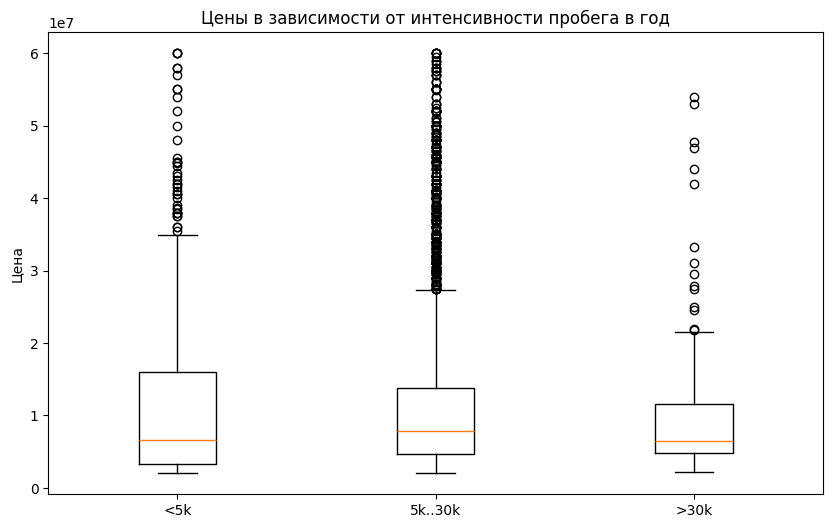

In [4548]:
lmp = df[df["has_low_mileage"] == 1]["price"]
hmp = df[df["has_high_mileage"] == 1]["price"]
mmp = df[(df["has_low_mileage"] == 0) & (df["has_high_mileage"] == 0)]["price"]

ss = [low_mileage_prices, medium_mileage_prices, high_mileage_prices]
plt.figure(figsize=(10, 6))
plt.boxplot(ss, labels=['<5k', '5k..30k', '>30k'])
plt.title("Цены в зависимости от интенсивности пробега в год")
plt.ylabel("Цена")
plt.show()

Видно, что чем меньше интенсивность пробега в год, тем выше цена на авто

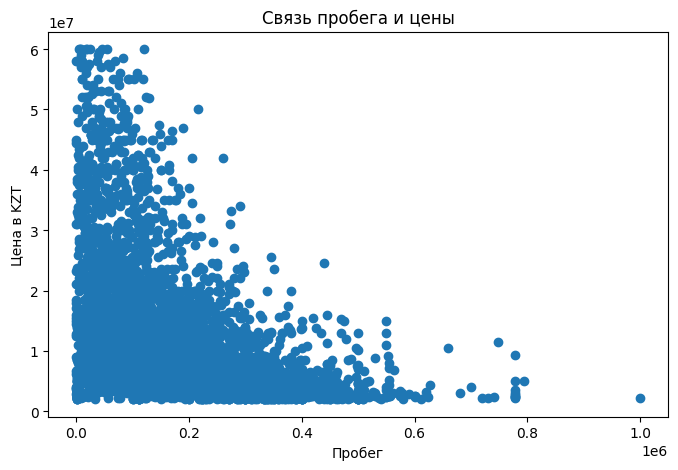

In [4549]:
plt.figure(figsize=(8, 5))
plt.scatter(df["mileage"], df["price"])
plt.title("Связь пробега и цены")
plt.xlabel("Пробег")
plt.ylabel("Цена в KZT")
plt.show()

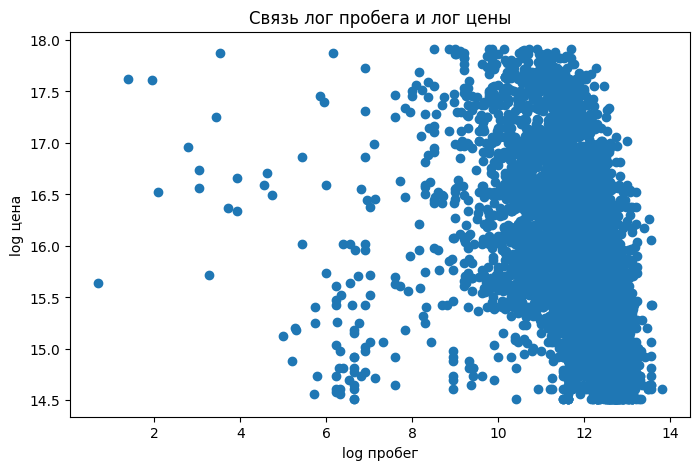

In [4550]:
plt.figure(figsize=(8, 5))
plt.scatter(df["log_mileage"], df["target_log_price"])
plt.title("Связь лог пробега и лог цены")
plt.xlabel("log пробег")
plt.ylabel("log цена")
plt.show()

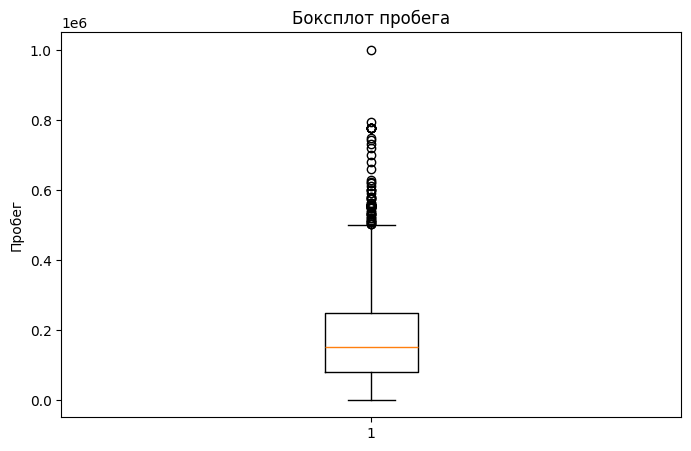

In [4551]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["mileage"])
plt.title("Боксплот пробега")
plt.ylabel("Пробег")
plt.show()

In [4552]:
df["mileage"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,mileage
0.01,777.0
0.05,16000.0
0.25,80000.0
0.50,152000.0
0.75,248000.0
0.95,400000.0
0.99,530837.2


mileage не содержит пропусков и отрицательных значений. Распределение имеет длинный правый хвост. Медиана 152 тыс. км, но есть выше 500 тыс. км. Также есть очень маленькие пробеги, которые относится к новым автомобилям

Дополнительно создали mileage_per_year и log_mileage_per_year. has_low_mileage и has_high_mileage - сделали флаги о том, что авто пользуются активно или неактивно

In [4553]:
df = df.drop(columns=["city"])

## 9. Transmission, drive type и steering wheel

steering_wheel бинарный, поэтому Слева = 1, Справа = 0.

transmission категориальный, потому что у него несколько значений: автомат, механика, робот, вариатор, оставим его таким+ создадим бинарный признак is_automatic_like через который красим авто с авто коробкой. Это может быть полезным, потому что боксплот показал авто на механике - дешевле

In [4554]:
df["steering_wheel"] = df["steering_wheel"].replace({"Слева": 1, "Справа": 0}).astype(int)

/tmp/ipykernel_3938/548668368.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["steering_wheel"] = df["steering_wheel"].replace({"Слева": 1, "Справа": 0}).astype(int)


In [4555]:
df["is_automatic_like"] = 0
df.loc[df["transmission"].isin(["Автомат", "Робот", "Вариатор"]), "is_automatic_like"] = 1

## 10. body_type

body_type описывает тип кузова. Часть типов кузова близки между собой по смыслу, поэтому дополнительно создаем более общий признак body_segment

In [4556]:
df["body_segment"] = "other"

df.loc[df["body_type"].isin(["Кроссовер", "Внедорожник"]), "body_segment"] = "suv_like"
df.loc[df["body_type"].isin(["Седан", "Лифтбек"]), "body_segment"] = "sedan_like"
df.loc[df["body_type"].isin(["Хэтчбек", "Универсал"]), "body_segment"] = "compact_wagon"
df.loc[df["body_type"].isin(["Минивэн", "Микровэн", "Микроавтобус", "Фургон"]), "body_segment"] = "van_like"
df.loc[df["body_type"].isin(["Купе", "Кабриолет", "Родстер"]), "body_segment"] = "sport_open"
df.loc[df["body_type"] == "Пикап", "body_segment"] = "pickup"

## 11. imgs_count

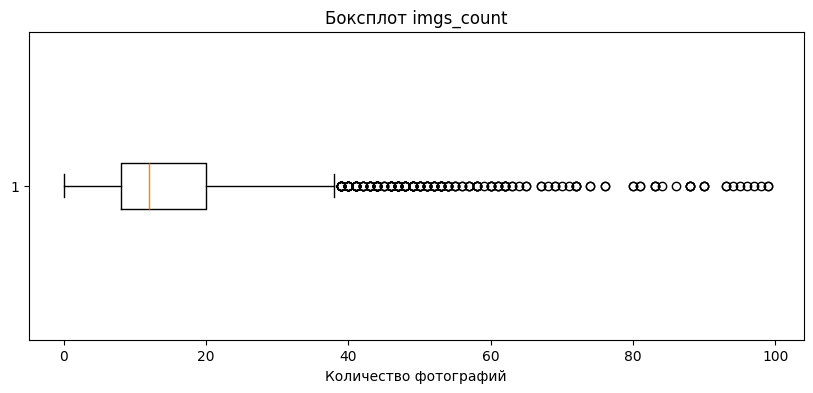

In [4557]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["imgs_count"], vert=False)

plt.title("Боксплот imgs_count")
plt.xlabel("Количество фотографий")
plt.show()

imgs_count показывает количество фотографий в объявлении.

Тк распределение количества фотографий имеет правый хвост, дополнительно создаем log_imgs_count

Также добавляем два бинарных признака: has_few_photos мало фотографий, если  <= 3, has_many_photos - много фотографий, если >= 15

In [4558]:
df["log_imgs_count"] = np.log1p(df["imgs_count"])

df["has_few_photos"] = 0
df.loc[df["imgs_count"] <= 3, "has_few_photos"] = 1

df["has_many_photos"] = 0
df.loc[df["imgs_count"] >= 15, "has_many_photos"] = 1

In [4559]:
df["brand_model"] = df["brand"] + "__" + df["model"]

In [4560]:
df.columns

Index(['brand', 'model', 'year', 'body_type', 'fuel_type', 'engine_volume',
       'mileage', 'transmission', 'drive_type', 'steering_wheel',
       'kz_registration', 'imgs_count', 'price', 'g_start_year', 'g_end_year',
       'g_is_current', 'g_number', 'g_is_restyling', 'g_age_car_release',
       'g_span', 'generation_number_missing', 'target_log_price', 'is_premium',
       'city_name', 'region', 'city_tier', 'is_big_city', 'is_electric',
       'car_age', 'is_new_car', 'is_recent_car', 'is_old_car', 'age_bucket',
       'is_metallic', 'base_color', 'color_known', 'log_mileage',
       'mileage_per_year', 'log_mileage_per_year', 'has_low_mileage',
       'has_high_mileage', 'is_automatic_like', 'body_segment',
       'log_imgs_count', 'has_few_photos', 'has_many_photos', 'brand_model'],
      dtype='object')

# Split

In [4561]:
df["price_bin"] = pd.qcut(df["target_log_price"], q=5, labels=False)

In [4562]:
df[['price', 'price_bin']].head(20)

,price,price_bin
0,4490000,1
1,6400000,1
2,7150000,2
3,4400000,1
4,2450000,0
5,5200000,1
6,2900000,0
7,3190000,0
8,6000000,1
9,4900000,1


In [4563]:
from sklearn.model_selection import train_test_split

df["price_bin"] = pd.qcut(df["target_log_price"], q=5, labels=False)

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=13062026, stratify=df["price_bin"])

val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=13062026, stratify=temp_df["price_bin"])

train_df = train_df.drop(columns=["price_bin"])
val_df = val_df.drop(columns=["price_bin"])
test_df = test_df.drop(columns=["price_bin"])

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(3698, 47)
(793, 47)
(793, 47)


In [4564]:
print(train_df["price"].describe())
print(val_df["price"].describe())
print(test_df["price"].describe())

count    3.698000e+03
mean     1.128115e+07
std      1.049681e+07
min      2.000000e+06
25%      4.500000e+06
50%      7.700000e+06
75%      1.354125e+07
max      6.000000e+07
Name: price, dtype: float64
count    7.930000e+02
mean     1.131688e+07
std      1.018358e+07
min      2.000000e+06
25%      4.650000e+06
50%      7.800000e+06
75%      1.400000e+07
max      6.000000e+07
Name: price, dtype: float64
count    7.930000e+02
mean     1.138166e+07
std      1.047294e+07
min      2.000000e+06
25%      4.600000e+06
50%      7.700000e+06
75%      1.400000e+07
max      6.000000e+07
Name: price, dtype: float64


In [4565]:
print(train_df["brand"].value_counts(normalize=True))
print(val_df["brand"].value_counts(normalize=True))
print(test_df["brand"].value_counts(normalize=True))

brand
Mercedes-Benz    0.130882
Chevrolet        0.128989
Toyota           0.127907
Lexus            0.125473
Hyundai          0.123580
BMW              0.123039
Kia              0.122769
Audi             0.117361
Name: proportion, dtype: float64
brand
Lexus            0.139975
Audi             0.134931
Mercedes-Benz    0.129887
BMW              0.128625
Kia              0.123581
Hyundai          0.121059
Toyota           0.114754
Chevrolet        0.107188
Name: proportion, dtype: float64
brand
Toyota           0.133670
BMW              0.133670
Mercedes-Benz    0.131148
Kia              0.127364
Lexus            0.124842
Hyundai          0.122320
Audi             0.114754
Chevrolet        0.112232
Name: proportion, dtype: float64


In [4566]:
print(train_df["target_log_price"].describe())
print(val_df["target_log_price"].describe())
print(test_df["target_log_price"].describe())

count    3698.000000
mean       15.913617
std         0.784241
min        14.508658
25%        15.319588
50%        15.856731
75%        16.421250
max        17.909855
Name: target_log_price, dtype: float64
count    793.000000
mean      15.919680
std        0.789632
min       14.508658
25%       15.352378
50%       15.869634
75%       16.454568
max       17.909855
Name: target_log_price, dtype: float64
count    793.000000
mean      15.922850
std        0.785888
min       14.508658
25%       15.341567
50%       15.856731
75%       16.454568
max       17.909855
Name: target_log_price, dtype: float64


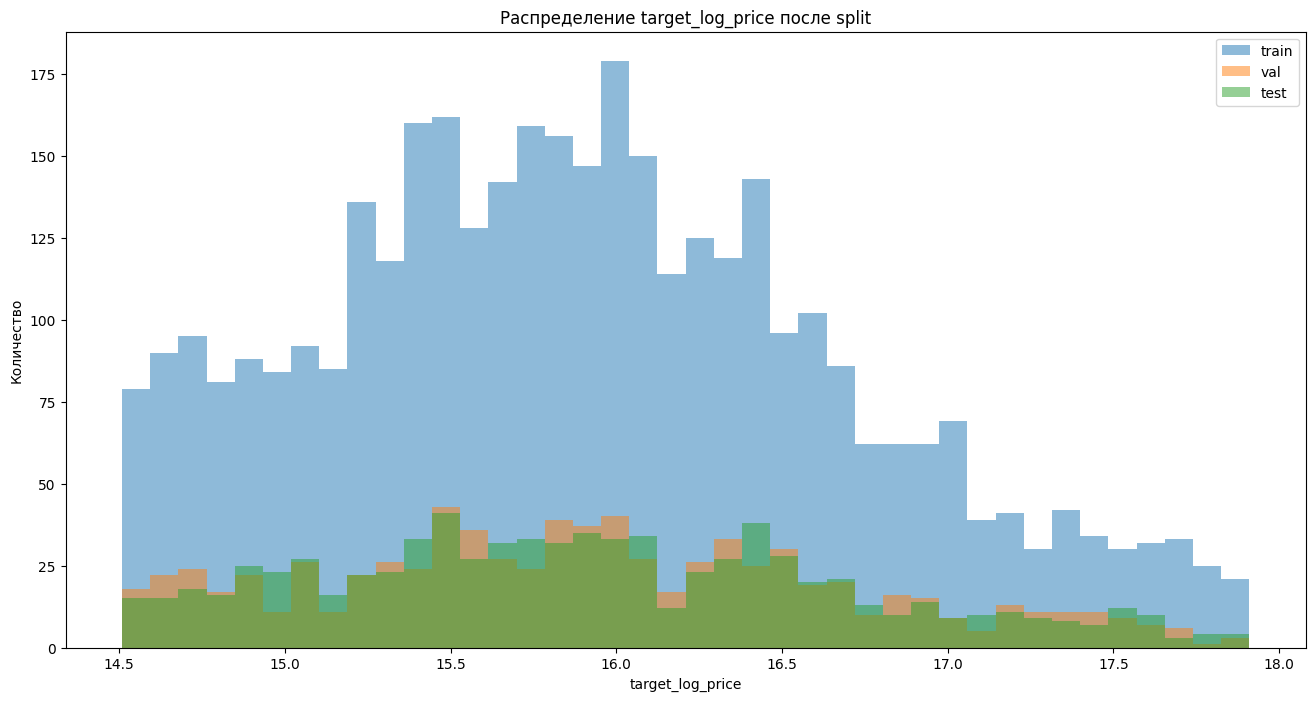

In [4567]:
plt.figure(figsize=(16, 8))

plt.hist(train_df["target_log_price"], bins=40, alpha=0.5, label="train")
plt.hist(val_df["target_log_price"], bins=40, alpha=0.5, label="val")
plt.hist(test_df["target_log_price"], bins=40, alpha=0.5, label="test")

plt.legend()
plt.title("Распределение target_log_price после split")
plt.xlabel("target_log_price")
plt.ylabel("Количество")
plt.show()

In [4568]:
y_train = train_df["target_log_price"]
y_val = val_df["target_log_price"]
y_test = test_df["target_log_price"]

X_train = train_df.drop(columns=["price", "target_log_price"])
X_val = val_df.drop(columns=["price", "target_log_price"])
X_test = test_df.drop(columns=["price", "target_log_price"])

После разбиения на train/val/test распределение целевой target_log_price осталось стабильным. Mean, медиана, std и диапазон значений почти совпадают во всех трех выборках. Поэтому полученный split можно считать корректным.

In [4569]:
df = df.drop(columns=["price_bin"])

In [4570]:
df.to_csv("outputs/final_dataset_before_split.csv", index=False, encoding="utf-8-sig")

train_df.to_csv("outputs/train_df.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("outputs/val_df.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("outputs/test_df.csv", index=False, encoding="utf-8-sig")

X_train.to_csv("outputs/X_train.csv", index=False, encoding="utf-8-sig")
X_val.to_csv("outputs/X_val.csv", index=False, encoding="utf-8-sig")
X_test.to_csv("outputs/X_test.csv", index=False, encoding="utf-8-sig")

y_train.to_frame("target_log_price").to_csv("outputs/y_train.csv", index=False, encoding="utf-8-sig")
y_val.to_frame("target_log_price").to_csv("outputs/y_val.csv", index=False, encoding="utf-8-sig")
y_test.to_frame("target_log_price").to_csv("outputs/y_test.csv", index=False, encoding="utf-8-sig")